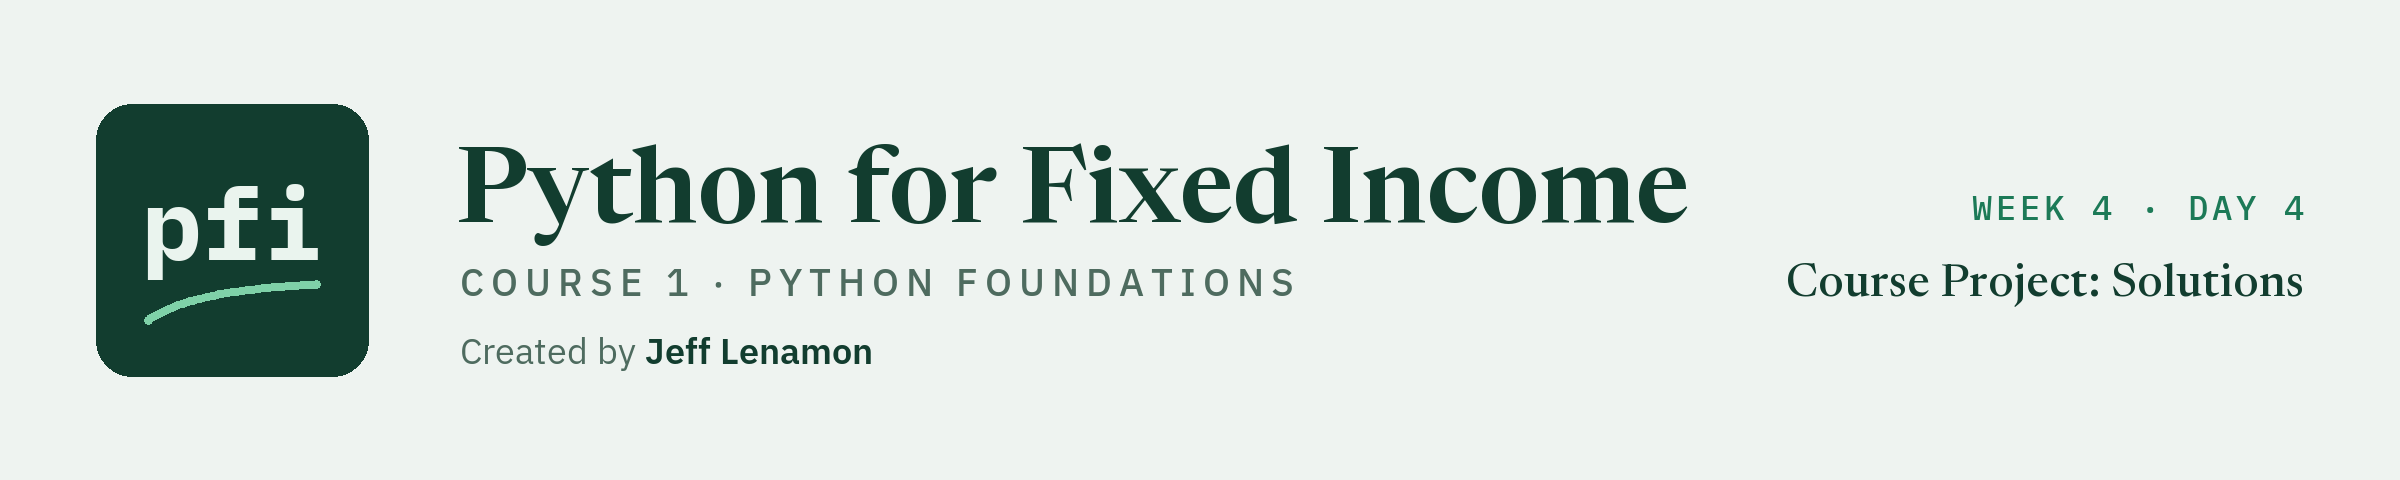

# Course Project - Solutions

Week 4, days 4 and 5. The worked version of the Course 1 project: every question answered with code, its output, and what the output shows. Write your own answers and your own conclusion first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day4/course1_project_solutions.ipynb)

## The brief

### The scenario

It is month end. You are the analyst on the credit desk, and the operations team has sent the holdings extract for 2026-10-30 with a cover note. The portfolio manager wants a written picture of the book before the month-end meeting: what is in it, where it is concentrated, whether the file can be trusted, and how the book differs from its benchmark.

This is the same desk and the same kind of extract as week 3, one month later. It is a new file. What was wrong with the September extract tells you nothing about what is wrong with this one. Run the routine, do not remember it.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name here refers to a real company.

### The cover note

```
To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-10-30

The month-end extract is attached as project_holdings.csv.

Control totals for the book:
  Number of bonds:      206
  Total face:           507,250,000 dollars
  Total market value:   509,928,477.50 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions are priced as of 2026-10-30.
Please tell us if the extract does not agree with these totals.
```

The note is also in the course repo as `data/project_cover_note.txt`.

### What to hand in

This notebook, completed: every code cell filled in and run from top to bottom, every decision written down, and the written conclusion of section 9.

### How long

Two days.

| Day | Sections |
| --- | --- |
| Week 4, day 4 | 1 structure, 2 data types, 3 sanity checks and data quality, 4 missing values, 5 summary statistics |
| Week 4, day 5 | 6 one column at a time, 7 two or more columns, 8 the desk's questions, 9 the conclusion |

Day 4 ends with a table you trust. Day 5 describes it.

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.2 makes the working copy, `book`, and every fix is made to `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and what evidence in the files supports it.
3. **Print the headline numbers before and after every fix.** The setup cell gives you `headline()` for that.
4. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector.
5. **Charts are finished charts.** A title, a label on each axis, and the unit.
6. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

* Every earlier notebook of the course, and your own notes.
* The documentation of pandas, matplotlib, and seaborn.
* An AI assistant, used the way the course taught: read the code it gives you, predict what it will print, run it, and check the result against a number you worked out yourself or against a control total. An answer you cannot check is not finished. Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_3_2`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. A check tests the number. It does not test your reasoning, and charts and written answers have no check: each of those questions says what a good answer includes.

Your cleaning decisions change the numbers that follow. Where a check depends on a decision, the question states the decision the check expects. A different decision can be defensible. If you make one, say so in a markdown cell and expect the check to disagree.

After section 4 there is a checkpoint cell that tests your cleaned table against the cover note. Do not go on to day 5 until it passes.

Worked answers are in `course1_project_solutions.ipynb` in this folder. Open it after you have written your own conclusion.

## The data

Three files. Units: **`coupon` and `yield_pct` are in percent, `oas` is in basis points, `duration` is in years, `price` and `accrued` are per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` are in dollars.**

**`project_holdings.csv`**: the extract. One row should be one bond the desk holds.

| Column | Meaning | Units |
| --- | --- | --- |
| `as_of_date` | the date the book is valued | year-month-day |
| `cusip` | the bond's identifier, nine characters | text |
| `ticker` | the issuer's ticker, four capital letters | text |
| `issuer` | the issuer's name | text |
| `sector` | one of ten sectors | text |
| `rating` | the bond's rating, from AAA to CCC | text |
| `coupon` | annual coupon rate | percent |
| `maturity` | the date the bond repays | year-month-day |
| `price` | clean price | per 100 of face |
| `price_date` | the date of the price | year-month-day |
| `accrued` | accrued interest | per 100 of face |
| `yield_pct` | yield to maturity | percent |
| `oas` | option-adjusted spread, a whole number | basis points |
| `duration` | modified duration | years |
| `spread_duration` | spread duration, equal to the duration for these bonds | years |
| `dts` | duration times spread: spread duration times OAS, to one decimal place | years times basis points |
| `amount_outstanding` | face of the whole issue | dollars |
| `par_held` | face the desk holds | dollars |
| `market_value` | face held times (price plus accrued), divided by 100 | dollars |

**`ratings.csv`**: the rating scale, 18 rows. `rating`, `score` (1 for AAA up to 18 for CCC, so a higher score is a lower rating), `bucket` (the rating without its plus or minus), and `grade` (Investment Grade or High Yield).

**`benchmark.csv`**: the benchmark the book is measured against, 821 bonds. It has the same columns as the extract with two differences: there is no `par_held`, and there is a `weight_pct` column, the weight of each bond in the benchmark in percent. Its `market_value` is that of the whole issue. **The benchmark file is the September file, as of 2026-09-30.** The desk has not been sent an October one. In this project the book is compared with it by sector weights and by rating bucket weights only, and the conclusion says that the two files are a month apart.

## Setup

Run this cell first. It is complete: do not change it. It imports the libraries, loads the three files, stores the control totals from the cover note, and defines two helpers: `headline()`, which prints the headline numbers of a table, and `check()`, which marks your answers. It prints the three shapes: (209, 19), (18, 4), and (821, 19).

In [1]:
# os is used to find the data folder
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/project_holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the extract exactly as it arrived. Nothing you write should change it.
raw = pd.read_csv(data_folder + 'project_holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the control totals from the cover note
expected_bonds = 206
expected_face = 507_250_000
expected_value = 509_928_477.50


def headline(label, table):
    # the headline numbers, to print before and after every fix
    print(label)
    print('   rows:', len(table))
    print('   face:', table['par_held'].sum(), 'dollars')
    print('   market value:', table['market_value'].sum(), 'dollars')
    print('   mean OAS:', round(table['oas'].mean(), 2), 'basis points')


def check(label, answer, expected):
    """Compare an answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


print('raw:', raw.shape, ' ratings:', ratings.shape, ' benchmark:', benchmark.shape)

raw: (209, 19)  ratings: (18, 4)  benchmark: (821, 19)


## 1 The structure of the data

### 1.1 Rows and columns

Q. How many rows and columns does the extract have? Store the shape, a pair of numbers (rows, columns), in **answer_1_1**, and show the first five rows. In a sentence, say what one row of this file is.

In [2]:
# shape is a pair: (rows, columns)
answer_1_1 = raw.shape
print('Rows and columns:', answer_1_1)

raw.head()

Rows and columns: (209, 19)


,as_of_date,cusip,ticker,issuer,sector,rating,coupon,maturity,price,price_date,accrued,yield_pct,oas,duration,spread_duration,dts,amount_outstanding,par_held,market_value
0,2026-10-30,99080CAE8,BEZE,Bezane Finance,Financials,BBB-,7.000,2032-06-18,106.576,2026-10-30,2.567,5.620,149.0,4.545,4.545,677.2,1650000000,4000000,4365720.0
1,2026-10-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.242,2026-10-30,0.293,9.402,554.0,2.171,2.171,1202.7,950000000,250000,243837.5
2,2026-10-30,99049XAE2,BEZH,Bezamyth Machinery,Industrials,B,8.125,2029-04-17,97.242,2026-10-30,0.293,9.402,554.0,2.171,2.171,1202.7,950000000,250000,243837.5
3,2026-10-30,99039NAC0,BEZL,Bezoquil Freight,Transportation,BB,5.125,2030-06-03,98.848,2026-10-30,2.093,5.481,151.0,3.169,3.169,478.5,850000000,1500000,1514115.0
4,2026-10-30,99039NAF3,BEZL,Bezoquil Freight,Transportation,BB,4.875,2035-11-15,93.286,2026-10-30,2.234,5.841,153.0,6.975,6.975,1067.2,300000000,3750000,3582000.0


* 209 rows and 19 columns. One row should be one bond the desk holds, valued on the as-of date.
* The cover note says 206 bonds. The file has 3 rows more than the book it describes, before a single value has been read.
* The 19 columns are those of the week 3 extract, in the same order, so week 3 code runs on this file.

In [3]:
check('Question 1.1', answer_1_1, (209, 19))

Question 1.1: correct


### 1.2 Identifiers and dates

Q. How many different as-of dates, CUSIPs, tickers, and issuer names are in the file? Store the number of different CUSIPs in **answer_1_2**.

In [4]:
# nunique() counts the different values in a column
print('As-of dates:', raw['as_of_date'].unique().tolist())

answer_1_2 = raw['cusip'].nunique()
print('Different CUSIPs:', answer_1_2, 'in', len(raw), 'rows')
print('Different tickers:', raw['ticker'].nunique())
print('Different issuer names:', raw['issuer'].nunique())

As-of dates: ['2026-10-30']
Different CUSIPs: 206 in 209 rows
Different tickers: 113
Different issuer names: 113


* One as-of date, 2026-10-30, as the cover note says.
* 206 different CUSIPs in 209 rows. 206 is the cover note's number of bonds, so some CUSIP is in the file more than once. Section 3 finds which.
* 113 tickers and 113 issuer names. One ticker per issuer, and the two counts agree.

In [5]:
check('Question 1.2', answer_1_2, 206)

Question 1.2: correct


## 2 Data types

### 2.1 The type of each column

Q. What type did pandas give each column? Count the columns held as numbers and store the count in **answer_2_1**. In a sentence, say which columns hold dates and what type they have.

In [6]:
print(raw.dtypes)

# counted from the list: float64 and int64 are numbers
answer_2_1 = 11

as_of_date                str
cusip                     str
ticker                    str
issuer                    str
sector                    str
rating                    str
coupon                float64
maturity                  str
price                 float64
price_date                str
accrued               float64
yield_pct             float64
oas                   float64
duration              float64
spread_duration       float64
dts                   float64
amount_outstanding      int64
par_held                int64
market_value          float64
dtype: object


* 11 columns are numbers: nine `float64` and two `int64`. The other eight are text, shown as `str`. Older versions of pandas print `object`.
* Three of the text columns are dates: `as_of_date`, `maturity`, and `price_date`. `read_csv` left them as text, as it did in week 3.
* `oas` is `float64`. The data dictionary says the OAS is a whole number of basis points, and in the week 3 file the same column was `int64`. A column of whole numbers that pandas reads as `float64` is worth a second look. Section 4 finds the reason.

In [7]:
check('Question 2.1', answer_2_1, 11)

Question 2.1: correct


### 2.2 A working copy with real dates

Q. Make a working copy of `raw` called `book`, and convert its three date columns to dates. Count the dates that could not be read, over the three columns, and store the count in **answer_2_2**. Print the earliest and the latest value of each date column.

From here on every fix is made to `book`, and `raw` stays as it arrived.

In [8]:
# book is the working copy. raw is not changed again.
book = raw.copy()

answer_2_2 = 0
for column in ['as_of_date', 'maturity', 'price_date']:
    # errors='coerce' turns text that is not a date into a missing date, so count those straight away
    book[column] = pd.to_datetime(book[column], format='%Y-%m-%d', errors='coerce')
    unread = book[column].isna().sum()
    answer_2_2 = answer_2_2 + unread
    print(column, '- type:', book[column].dtype, ' not read:', unread,
          ' earliest:', book[column].min().date(), ' latest:', book[column].max().date())

as_of_date - type: datetime64[us]  not read: 0  earliest: 2026-10-30  latest: 2026-10-30
maturity - type: datetime64[us]  not read: 0  earliest: 2019-10-21  latest: 2056-07-24
price_date - type: datetime64[us]  not read: 0  earliest: 2026-10-30  latest: 2026-10-30


* All three columns are dates now, and 0 values failed to convert.
* `as_of_date` and `price_date` each run from 2026-10-30 to 2026-10-30: one date.
* `maturity` runs from 2019-10-21 to 2056-07-24. The earliest maturity is seven years before the as-of date. A bond that has matured is not a holding. Section 3 tests it as a rule.

In [9]:
check('Question 2.2', answer_2_2, 0)

Question 2.2: correct


## 3 Sanity checks and data quality

A sanity check asks a question whose answer is known before looking. This section is the longest of day 4. Work through it in order: the cover note first, then the rows, the identifiers, the categories, the values, the dates, and whether the file agrees with itself. It ends with the cover note again.

### 3.1 The file against the cover note

Q. Print the headline numbers of the extract as received. Then print the difference between the file and the cover note, file less cover note, for the number of rows, the total face, and the total market value. Store the difference in rows in **answer_3_1**. In a sentence, say what the three differences suggest.

In [10]:
headline('As received', raw)

# each figure less the cover note's
answer_3_1 = len(raw) - expected_bonds
print('Rows less cover note:', answer_3_1)
print('Face less cover note:', raw['par_held'].sum() - expected_face, 'dollars')
print('Market value less cover note:', round(raw['market_value'].sum() - expected_value, 2), 'dollars')

As received
   rows: 209
   face: 507000000 dollars
   market value: 516229847.5 dollars
   mean OAS: 192.18 basis points
Rows less cover note: 3
Face less cover note: -250000 dollars
Market value less cover note: 6301370.0 dollars


* As received: 209 rows, 507,000,000 dollars of face, 516,229,847.5 dollars of market value, and a mean OAS of 192.18 basis points.
* 3 rows too many, and 6,301,370.0 dollars of market value too much. The face is 250,000 dollars too little.
* The differences do not point the same way. Extra rows would add face as well as market value, and the face is short. One problem cannot do both, so there are at least two.

In [11]:
check('Question 3.1', answer_3_1, 3)

Question 3.1: correct


### 3.2 Repeated rows

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_3_2**. Show each copy next to the row it repeats, with the face and market value the copies carry.

**Expected decision:** remove exact duplicate rows, keeping the first of each. Print the headline numbers before and after, and the differences from the cover note after.

In [12]:
# duplicated() marks a row that matches an earlier row in every column
answer_3_2 = book.duplicated().sum()
print('Rows that repeat an earlier row:', answer_3_2)
print('CUSIPs that repeat an earlier CUSIP:', book['cusip'].duplicated().sum())

# what the copies carry
print('Face in the copies:', book.loc[book.duplicated(), 'par_held'].sum(), 'dollars')
print('Market value in the copies:', book.loc[book.duplicated(), 'market_value'].sum(), 'dollars')

# keep=False marks the first appearance as well as the copy
book.loc[book.duplicated(keep=False), ['cusip', 'ticker', 'issuer', 'par_held', 'market_value']]

Rows that repeat an earlier row: 3
CUSIPs that repeat an earlier CUSIP: 3
Face in the copies: 6250000 dollars
Market value in the copies: 6301370.0 dollars


,cusip,ticker,issuer,par_held,market_value
1,99049XAE2,BEZH,Bezamyth Machinery,250000,243837.5
2,99049XAE2,BEZH,Bezamyth Machinery,250000,243837.5
175,99085HAA0,TROR,Tromazor Resources,2250000,2244870.0
176,99085HAA0,TROR,Tromazor Resources,2250000,2244870.0
186,99006GAC4,VYRH,Veyrholt Health,3750000,3812662.5
187,99006GAC4,VYRH,Veyrholt Health,3750000,3812662.5


* 3 rows are exact copies, and they are the 3 repeated CUSIPs. No CUSIP is repeated with different values.
* The row labels show where they are: each copy is directly below its original, at rows 2, 176, and 187. In the week 3 file the copies were the last rows of the file. A check that only looked at the end of this file would find nothing.
* The copies carry 6,250,000 dollars of face and 6,301,370.0 dollars of market value. The second figure is the market value difference from the cover note, to the dollar.

**Decision 1.** Remove the 3 repeated rows, keeping the first of each. Evidence: they match an earlier row in all 19 columns, and their market value is exactly the excess over the control total.

In [13]:
headline('Before', book)

# drop_duplicates() keeps the first appearance. reset_index(drop=True) renumbers the rows from 0.
book = book.drop_duplicates().reset_index(drop=True)

headline('After', book)
print('Every CUSIP appears once:', book['cusip'].is_unique)
print('Face less cover note:', book['par_held'].sum() - expected_face, 'dollars')
print('Market value less cover note:', round(book['market_value'].sum() - expected_value, 2), 'dollars')

Before
   rows: 209
   face: 507000000 dollars
   market value: 516229847.5 dollars
   mean OAS: 192.18 basis points
After
   rows: 206
   face: 500750000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
Every CUSIP appears once: True
Face less cover note: -6500000 dollars
Market value less cover note: 0.0 dollars


* 209 rows became 206, the cover note's number. The market value went from 516,229,847.5 to 509,928,477.5 dollars and now matches the control total with a difference of 0.0.
* The mean OAS moved from 192.18 to 190.21 basis points.
* The face went from 507,000,000 to 500,750,000 dollars, and its difference from the cover note grew from -250,000 to -6,500,000. Removing one problem uncovered the size of another: the extra face in the copies had been hiding most of a shortfall somewhere else.
* In Excel: Data, Remove Duplicates on a copy of the sheet, after `=COUNTIF($B$2:$B$210, B2) > 1` filled down has shown which rows repeat. The CUSIP is in column B.

In [14]:
check('Question 3.2', answer_3_2, 3)

Question 3.2: correct


### 3.3 Identifiers

Q. Check the identifiers of `book`. Is every CUSIP nine characters long, and is each one there once? Is every CUSIP also in `benchmark.csv`? Is every ticker free of stray spaces and lower case? Store the number of CUSIPs that are **not** found in the benchmark in **answer_3_3**.

In [15]:
# str.len() gives the number of characters in each value
print(book['cusip'].str.len().value_counts())
print('Every CUSIP appears once:', book['cusip'].is_unique)

# isin() is True where the CUSIP is one of the benchmark's
in_benchmark = book['cusip'].isin(benchmark['cusip'])
answer_3_3 = (~in_benchmark).sum()
print('CUSIPs not in the benchmark:', answer_3_3)

# a ticker is tidy when stripping spaces and making capitals changes nothing
untidy_ticker = book['ticker'] != book['ticker'].str.strip().str.upper()
print('Untidy tickers:', untidy_ticker.sum())
print('Tickers:', book['ticker'].nunique(), ' issuer names:', book['issuer'].nunique())

cusip
9    206
Name: count, dtype: int64
Every CUSIP appears once: True
CUSIPs not in the benchmark: 0
Untidy tickers: 0
Tickers: 113  issuer names: 113


* All 206 CUSIPs have 9 characters, each appears once, and all 206 are bonds of the benchmark.
* 0 tickers are untidy, and there are 113 tickers for 113 issuer names. The ticker problem of the week 3 file is not in this one.
* Every check here passed. A clean result is a result: it goes in the write-up with the checks that were run.

In [16]:
check('Question 3.3', answer_3_3, 0)

Question 3.3: correct


### 3.4 Categories

Q. Are the category columns consistent? List every value of `sector` with its count, and test whether every `rating` is on the rating scale. Store the number of different values in the `sector` column of `book`, before any fix, in **answer_3_4**.

**Expected decision:** sector names that differ only in upper and lower case, or in spaces at the ends, are one sector. Tidy them. Print the number of different sectors before and after, and show what the fix does to the market value of one sector.

In [17]:
# every different value and how often it appears
print(book['sector'].value_counts())

answer_3_4 = book['sector'].nunique()
print('Different sector values:', answer_3_4)

# the tidy version: no spaces at the ends, a capital at the start of each word
tidy_sector = book['sector'].str.strip().str.title()
untidy_sector = book['sector'] != tidy_sector
print('Sector values that change when tidied:', untidy_sector.sum())

# tolist() prints each value in quotes, so that the spaces show
print(book.loc[untidy_sector, 'sector'].tolist())

# every rating should be one of the 18 on the scale
print('Ratings not on the scale:', (~book['rating'].isin(ratings['rating'])).sum())

sector
Financials         27
Materials          26
Telecom            24
Consumer           23
Transportation     21
Health Care        18
Industrials        17
Energy             15
Utilities          13
Technology         13
utilities           1
MATERIALS           1
Transportation      1
 consumer           1
industrials         1
TECHNOLOGY          1
Energy              1
 industrials        1
telecom             1
Name: count, dtype: int64
Different sector values: 19
Sector values that change when tidied: 9
['utilities', 'MATERIALS', 'Transportation ', ' consumer', 'industrials', 'TECHNOLOGY', 'Energy ', ' industrials', 'telecom']
Ratings not on the scale: 0


* 19 different values in a column that should have ten. The bottom nine rows of the list have a count of 1 each: `utilities`, `MATERIALS`, `TECHNOLOGY`, `telecom`, and so on.
* Two of them look right in the list and are not: `'Transportation '` and `'Energy '` end in a space, which only the quotes of `tolist()` show. Two more start with a space.
* 9 rows change when tidied. Every rating is on the scale.

**Decision 2.** Replace the sector of every row with its tidy version. Evidence: each of the 9 untidy values becomes one of the ten sector names once the spaces are stripped and the capitals set, and no new name appears.

In [18]:
# Industrials as the file has it: three spellings, three groups
before = book.groupby('sector')['market_value'].sum()
print('Before - different sectors:', book['sector'].nunique(), ' Industrials market value:', before.loc['Industrials'])

book['sector'] = book['sector'].str.strip().str.title()

after = book.groupby('sector')['market_value'].sum()
print('After  - different sectors:', book['sector'].nunique(), ' Industrials market value:', after.loc['Industrials'])
print('Difference:', after.loc['Industrials'] - before.loc['Industrials'], 'dollars')

headline('After', book)

Before - different sectors: 19  Industrials market value: 41916605.0
After  - different sectors: 10  Industrials market value: 50287460.0
Difference: 8370855.0 dollars
After
   rows: 206
   face: 500750000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points


* 19 sector values became 10, and 9 values changed. No row was added or removed.
* Grouped on the column as received, Industrials was 41,916,605.0 dollars. Tidied, it is 50,287,460.0. A sector report built on the raw column would have understated Industrials by 8,370,855.0 dollars and shown two extra one-bond sectors, with no error raised.
* The headline numbers do not move: 206 rows, 500,750,000 dollars of face, 509,928,477.5 of market value, 190.21 basis points. None of them is grouped by sector. A fix can matter for one report and not for another.
* In Excel: `=PROPER(TRIM(E2))` in a helper column, with the sector in column E.

In [19]:
check('Question 3.4', answer_3_4, 19)

Question 3.4: correct


### 3.5 Values that cannot be right

Q. Does any column of `book` hold a value that cannot be right for a bond the desk holds? Test at least these six rules and print the number of rows that break each:

* a price of zero or less
* a coupon of zero or less
* a duration of zero or less
* a face held of zero or less
* a face held above the amount outstanding
* a maturity on or before the as-of date

Store the total number of rule breaks, added over the six rules, in **answer_3_5**, and show the rows that break a rule. Do not fix anything yet.

In [20]:
# one mask for each rule. True marks a row that breaks it.
bad_price = book['price'] <= 0
bad_coupon = book['coupon'] <= 0
bad_duration = book['duration'] <= 0
bad_face = book['par_held'] <= 0
too_much_face = book['par_held'] > book['amount_outstanding']
bad_maturity = book['maturity'] <= book['as_of_date']

print('Price of zero or less:', bad_price.sum())
print('Coupon of zero or less:', bad_coupon.sum())
print('Duration of zero or less:', bad_duration.sum())
print('Face held of zero or less:', bad_face.sum())
print('Face held above the amount outstanding:', too_much_face.sum())
print('Maturity on or before the as-of date:', bad_maturity.sum())

answer_3_5 = (bad_price.sum() + bad_coupon.sum() + bad_duration.sum() + bad_face.sum()
              + too_much_face.sum() + bad_maturity.sum())
print('Rule breaks in total:', answer_3_5)

# | is "or": the rows that break either of the two rules that failed
book.loc[bad_face | bad_maturity, ['cusip', 'ticker', 'coupon', 'maturity', 'duration', 'par_held', 'market_value']]

Price of zero or less: 0
Coupon of zero or less: 0
Duration of zero or less: 0
Face held of zero or less: 2
Face held above the amount outstanding: 0
Maturity on or before the as-of date: 1
Rule breaks in total: 3


,cusip,ticker,coupon,maturity,duration,par_held,market_value
137,99032GAB4,QUEL,6.375,2035-02-01,6.279,-1250000,1297512.5
147,99046UAD3,SKEN,9.250,2019-10-21,2.550,1000000,1010360.0
187,99042QAA2,VYRR,4.875,2029-06-27,2.432,-2000000,2053200.0


* 3 rule breaks in 3 rows. Four of the six rules pass with a count of zero.
* 2 rows have a negative face: QUEL with -1,250,000 dollars and VYRR with -2,000,000. Both have a positive market value. The two add up to -3,250,000, and reversing the sign of both would add 6,500,000 dollars of face, the shortfall against the cover note.
* 1 row has a maturity before the as-of date: SKEN `99046UAD3`, with a maturity of 2019-10-21 and a duration of 2.55 years. A bond that matured seven years ago has no duration.
* These rules need no judgement. Deciding what the right values are does, and that is question 3.8.

In [21]:
check('Question 3.5', answer_3_5, 3)

Question 3.5: correct


### 3.6 Price dates

Q. Is every position priced at month end? Count the rows of `book` whose `price_date` is not the `as_of_date`, and store the count in **answer_3_6**.

In [22]:
# the rows whose price is dated on another day than the as-of date
answer_3_6 = (book['price_date'] != book['as_of_date']).sum()
print('Rows priced on another date:', answer_3_6)
print('Price dates run from', book['price_date'].min().date(), 'to', book['price_date'].max().date())

Rows priced on another date: 0
Price dates run from 2026-10-30 to 2026-10-30


* 0 rows. Every price is dated 2026-10-30, as the cover note says. The stale prices of the week 3 file are not in this one.
* The cover note made the claim and the file was tested against it. A claim that has been checked is worth more in the write-up than one that has been copied.

In [23]:
check('Question 3.6', answer_3_6, 0)

Question 3.6: correct


### 3.7 Does the file agree with itself?

Q. The cover note says market value is face times clean price plus accrued interest, divided by 100. Work that out for every row of `book` and compare it with the `market_value` column. Store the number of rows where the two differ by more than 1 dollar in **answer_3_7**, and show those rows. Do not fix anything yet.

In [24]:
# market value worked out from three other columns
worked_out = book['par_held'] * (book['price'] + book['accrued']) / 100

# the gap between that and the market_value column. abs() drops the sign.
gap = (worked_out - book['market_value']).abs()
no_tie = gap > 1

answer_3_7 = no_tie.sum()
print('Rows that do not tie out:', answer_3_7)
print('Largest gap in the other rows:', round(gap[~no_tie].max(), 2), 'dollars')
print('Prices in the other rows: from', book.loc[~no_tie, 'price'].min(), 'to', book.loc[~no_tie, 'price'].max())

book.loc[no_tie, ['cusip', 'ticker', 'rating', 'coupon', 'yield_pct', 'price', 'accrued', 'par_held', 'market_value']]

Rows that do not tie out: 5
Largest gap in the other rows: 0.0 dollars
Prices in the other rows: from 63.522 to 126.427


,cusip,ticker,rating,coupon,yield_pct,price,accrued,par_held,market_value
137,99032GAB4,QUEL,BBB-,6.375,6.027,102.22500,1.576,-1250000,1297512.5
173,99093PAB0,TROE,BB+,6.375,5.791,1.01860,2.639,2750000,2873722.5
187,99042QAA2,VYRR,AA-,4.875,4.472,100.99400,1.666,-2000000,2053200.0
197,99036KAA3,XANL,CCC,10.625,10.389,1.01346,2.833,3250000,3385817.5
200,99104AAD6,YARN,A-,4.375,4.937,9824.30000,0.304,1250000,1231837.5


* 5 rows do not tie out. In the other 201 the largest gap is 0.0 dollars.
* Two of the five are the rows with a negative face from question 3.5: QUEL and VYRR.
* The other three have a price that is far from every other price in the file: 1.0186 for TROE, 1.01346 for XANL, and 9,824.3 for YARN. The prices of the 201 rows that tie out run from 63.522 to 126.427.
* None of the three broke a rule in 3.5, because a price of 1.0186 is above zero. A rule catches the impossible. This check catches the inconsistent.
* In Excel: `=R2 * (I2 + K2) / 100 - S2` in a helper column, with the face in column R, the price in column I, the accrued interest in column K, and the market value in column S.

In [25]:
check('Question 3.7', answer_3_7, 5)

Question 3.7: correct


### 3.8 Decisions

Q. Read the rows found in 3.5 and 3.7. For each one, decide which column is wrong, and say what evidence in the files supports the decision. Then make the fixes, printing the headline numbers before and after each one.

**Expected decisions:**

* a face held with the wrong sign becomes the positive amount;
* a price in the wrong units is put back into price per 100 of face, rounded to 3 decimal places;
* a maturity that cannot be right is replaced with the maturity of the same CUSIP in `benchmark.csv`.

When the fixes are made, run the tests of 3.5 and 3.7 again. Store the number of rows that still fail any of them in **answer_3_8**.

**The face.** In each of the two rows either the face or the market value has the wrong sign. Which?

In [26]:
# what the market value would be with the sign of the face removed
positive_face = book.loc[bad_face, 'par_held'].abs()
with_positive_face = positive_face * (book.loc[bad_face, 'price'] + book.loc[bad_face, 'accrued']) / 100

print('Market value in the file:', book.loc[bad_face, 'market_value'].tolist())
print('Worked out from the positive face:', with_positive_face.round(2).tolist())

Market value in the file: [1297512.5, 2053200.0]
Worked out from the positive face: [1297512.5, 2053200.0]


* 1,297,512.5 and 2,053,200.0 dollars both ways. The market value in the file is the one the positive face gives, to the cent.

**Decision 3.** Make the face of the 2 rows positive. Evidence: the market value column agrees with the positive amount exactly, and the two corrections add up to the 6,500,000 dollars by which the face is short of the cover note.

In [27]:
headline('Before', book)

# abs() removes the sign
book.loc[bad_face, 'par_held'] = book.loc[bad_face, 'par_held'].abs()

headline('After', book)
print('Face less cover note:', book['par_held'].sum() - expected_face, 'dollars')

Before
   rows: 206
   face: 500750000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
Face less cover note: 0 dollars


* The face went from 500,750,000 to 507,250,000 dollars and now matches the cover note with a difference of 0. Rows, market value, and mean OAS are unchanged.

**The price.** In the three rows the price and the market value disagree. The market value, the face, and the accrued interest together imply a price.

In [28]:
# the price that the other three columns imply: market value over face, times 100, less accrued
implied_price = book['market_value'] / book['par_held'] * 100 - book['accrued']

# the three rows whose price is far outside the range of the rest
wrong_price = (book['price'] < 10) | (book['price'] > 1000)

evidence = book.loc[wrong_price, ['cusip', 'ticker', 'coupon', 'yield_pct', 'price']].copy()
evidence['implied_price'] = implied_price[wrong_price].round(3)
print(evidence)

         cusip ticker  coupon  yield_pct       price  implied_price
173  99093PAB0   TROE   6.375      5.791     1.01860        101.860
197  99036KAA3   XANL  10.625     10.389     1.01346        101.346
200  99104AAD6   YARN   4.375      4.937  9824.30000         98.243


* The implied prices are 101.86, 101.346, and 98.243. The prices in the file are 1.0186, 1.01346, and 9,824.3: the same digits with the decimal point two places out. Two were entered at a hundredth of the price and one at a hundred times it.
* The other columns agree with the implied prices. TROE has a 6.375 percent coupon and a 5.791 percent yield: a yield below the coupon goes with a price above 100, and 101.86 is. YARN has a 4.375 percent coupon and a 4.937 percent yield, and 98.243 is below 100.

**Decision 4.** Multiply the 2 prices below 10 by 100 and divide the 1 price above 1,000 by 100. Evidence: each corrected price reproduces the market value in the file to the cent and is on the right side of 100 for its coupon and yield. The market value column is left alone.

In [29]:
too_low = book['price'] < 10
too_high = book['price'] > 1000

headline('Before', book)
print('   mean price:', round(book['price'].mean(), 3), ' median price:', round(book['price'].median(), 3))

# round(3) keeps three decimal places, like the rest of the column
book.loc[too_low, 'price'] = (book.loc[too_low, 'price'] * 100).round(3)
book.loc[too_high, 'price'] = (book.loc[too_high, 'price'] / 100).round(3)

headline('After', book)
print('   mean price:', round(book['price'].mean(), 3), ' median price:', round(book['price'].median(), 3))

Before
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
   mean price: 145.043  median price: 99.389
After
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
   mean price: 98.806  median price: 99.474


* The four headline numbers do not change, because none of them uses the price. The mean price does: 145.043 as received and 98.806 corrected. One price of 9,824.3 among 206 was enough to move the mean by about 46 points. The median moved from 99.389 to 99.474, less than a tenth of a point. A mean takes in the full size of an error and a median mostly ignores it.

**The maturity.** The extract cannot say what the maturity should be. The benchmark file lists the same bond.

In [30]:
# the CUSIP of the row, and the same CUSIP in the benchmark
bad_cusip = book.loc[bad_maturity, 'cusip'].iloc[0]
benchmark_row = benchmark[benchmark['cusip'] == bad_cusip]

print('In the extract:')
print(book.loc[bad_maturity, ['cusip', 'ticker', 'coupon', 'maturity', 'duration']])
print('In the benchmark:')
print(benchmark_row[['cusip', 'ticker', 'coupon', 'maturity']])

In the extract:
         cusip ticker  coupon   maturity  duration
147  99046UAD3   SKEN    9.25 2019-10-21      2.55
In the benchmark:
         cusip ticker  coupon    maturity
237  99046UAD3   SKEN    9.25  2029-10-21


* The benchmark has the same CUSIP, the same ticker, and the same 9.25 percent coupon, with a maturity of 2029-10-21: the same month and day, ten years later.
* A maturity in October 2029 is three years after the as-of date, which fits the duration of 2.55 years in the extract. A maturity in 2019 fits nothing.

**Decision 5.** Replace the maturity of the 1 row with the benchmark's, 2029-10-21. Evidence: the same CUSIP in a second file, and a duration in the extract that agrees with it.

In [31]:
headline('Before', book)

# the benchmark's maturity is text, so make it a date before storing it
book.loc[bad_maturity, 'maturity'] = pd.Timestamp(benchmark_row['maturity'].iloc[0])

headline('After', book)
print('Maturity of', bad_cusip, 'is now', book.loc[bad_maturity, 'maturity'].iloc[0].date())
print('Earliest maturity in the book:', book['maturity'].min().date())

Before
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
Maturity of 99046UAD3 is now 2029-10-21
Earliest maturity in the book: 2027-10-02


* The headline numbers are unchanged. The earliest maturity in the book is now 2027-10-02, after the as-of date.

Now the tests again, on the corrected table.

In [32]:
# the six rules of 3.5 and the tie-out of 3.7, on the table as it now stands
rule_breaks = ((book['price'] <= 0).sum() + (book['coupon'] <= 0).sum() + (book['duration'] <= 0).sum()
               + (book['par_held'] <= 0).sum() + (book['par_held'] > book['amount_outstanding']).sum()
               + (book['maturity'] <= book['as_of_date']).sum())

worked_out = book['par_held'] * (book['price'] + book['accrued']) / 100
gap = (worked_out - book['market_value']).abs()

answer_3_8 = rule_breaks + (gap > 1).sum()
print('Rule breaks:', rule_breaks)
print('Rows that do not tie out:', (gap > 1).sum(), ' largest gap:', round(gap.max(), 2), 'dollars')

Rule breaks: 0
Rows that do not tie out: 0  largest gap: 0.0 dollars


* 0 rule breaks and 0 rows that do not tie out. The largest gap in any of the 206 rows is 0.0 dollars.

In [33]:
check('Question 3.8', answer_3_8, 0)

Question 3.8: correct


### 3.9 The cover note again

Q. Does the corrected table agree with the cover note? Print the three differences, table less cover note, and store the difference in market value, rounded to 2 decimal places, in **answer_3_9**.

In [34]:
answer_3_9 = round(book['market_value'].sum() - expected_value, 2)

print('Rows less cover note:', len(book) - expected_bonds)
print('Face less cover note:', book['par_held'].sum() - expected_face, 'dollars')
print('Market value less cover note:', answer_3_9, 'dollars')

Rows less cover note: 0
Face less cover note: 0 dollars
Market value less cover note: 0.0 dollars


* 0, 0, and 0.0. All three control totals match.
* Matching the control totals is necessary and it is not enough. The wrong prices, the sector spellings, and the maturity never touched a control total. Only the repeated rows and the negative face did.

In [35]:
check('Question 3.9', answer_3_9, 0.0)

Question 3.9: correct


## 4 Missing values

### 4.1 How many, and where

Q. How many values are missing in each column of `book`? Print the columns that have at least one. Store the total number of missing cells in **answer_4_1**.

In [36]:
# isna() is True for each missing cell, and sum() counts them by column
missing = book.isna().sum()
print(missing[missing > 0])

answer_4_1 = missing.sum()
print('Missing cells in the whole table:', answer_4_1)

oas    4
dtype: int64
Missing cells in the whole table: 4


* One column has gaps: `oas`, with 4. The other 18 columns are complete.
* This is why `oas` was `float64` in question 2.1. A column of whole numbers with an empty cell cannot be `int64`, because `NaN` is a decimal value, so pandas reads the whole column as decimals.
* In the week 3 file the gaps were in a text column, the rating. Here they are in a number column, and that changes what they do: a missing number drops out of every sum and mean without a message.
* In Excel: `=COUNTBLANK(M2:M207)` on the OAS column of the sheet with the copies removed, which returns 4.

In [37]:
check('Question 4.1', answer_4_1, 4)

Question 4.1: correct


### 4.2 Which bonds

Q. Show the rows with a missing value. What share of the book's market value are they? Store the share, in percent rounded to 2 decimal places, in **answer_4_2**. In a sentence, say whether the gaps share a sector, an issuer, or a rating.

In [38]:
# the rows where the OAS is missing
no_oas = book[book['oas'].isna()]

answer_4_2 = round(no_oas['market_value'].sum() / book['market_value'].sum() * 100, 2)
print('Market value of the rows:', no_oas['market_value'].sum(), 'dollars')
print('Share of the book:', answer_4_2, 'percent')

no_oas[['cusip', 'ticker', 'issuer', 'sector', 'rating', 'spread_duration', 'dts', 'market_value']]

Market value of the rows: 16957307.5 dollars
Share of the book: 3.33 percent


,cusip,ticker,issuer,sector,rating,spread_duration,dts,market_value
81,99078AAE6,HESA,Heskundra Retail,Consumer,A-,6.685,715.3,4886182.5
95,99087JAC0,KRIX,Krilellix Networks,Telecom,BBB-,4.631,889.2,4682012.5
98,99114KAA8,LORE,Lorvane Systems,Technology,BB-,1.810,689.6,2753162.5
146,99079BAC7,RULR,Rulvazor Utilities,Utilities,A+,7.753,441.9,4635950.0


* Four bonds of four issuers, HESA, KRIX, LORE, and RULR, with 16,957,307.5 dollars of market value, 3.33 percent of the book.
* No pattern: four sectors, Consumer, Telecom, Technology, and Utilities, and four ratings, A-, BBB-, BB-, and A+.
* Every other column of the four rows is filled in, including `spread_duration` and `dts`.

In [39]:
check('Question 4.2', answer_4_2, 3.33)

Question 4.2: correct


### 4.3 The decision

Q. What does each choice do to the numbers: leaving the gaps, dropping the rows, or filling them? Try the first two without changing `book`, and print the row count, the market value, and the mean OAS each gives.

**Expected decision:** the data dictionary says `dts` is spread duration times OAS. So a missing OAS can be worked out from two columns of its own row: `dts` divided by `spread_duration`, rounded to a whole basis point. Before you use that rule, test it on the rows where the OAS is present. Then fill the gaps, print the headline numbers before and after, and store the mean OAS of `book`, rounded to 2 decimal places, in **answer_4_3**.

In [40]:
# choice 1, leave: mean() skips the gaps, so it is a mean over fewer rows than the table has
print('Leave - mean OAS:', round(book['oas'].mean(), 2), 'over', book['oas'].count(), 'of', len(book), 'rows')

# choice 2, drop: dropna() removes the rows with a gap in the column named
dropped = book.dropna(subset=['oas'])
headline('Drop', dropped)
print('   market value less cover note:', round(dropped['market_value'].sum() - expected_value, 2), 'dollars')

Leave - mean OAS: 190.21 over 202 of 206 rows
Drop
   rows: 202
   face: 491000000 dollars
   market value: 492971170.0 dollars
   mean OAS: 190.21 basis points
   market value less cover note: -16957307.5 dollars


* Left alone, the mean OAS is 190.21 basis points, and it is a mean of 202 bonds presented as a mean of 206.
* Dropped, the table has 202 rows and 492,971,170.0 dollars, which is 16,957,307.5 short of the cover note. Four bonds the desk owns would leave the book because one cell in each is empty.

Now the third choice. Test the rule before trusting it.

In [41]:
# the OAS that DTS and spread duration imply, for every row
worked_out_oas = (book['dts'] / book['spread_duration']).round()

# notna() is True where a value is present
present = book['oas'].notna()

print('Rows with an OAS:', present.sum())
print('Of those, rows where the rule gives a different OAS:', (worked_out_oas[present] != book.loc[present, 'oas']).sum())
print('What the rule gives for the four gaps:', worked_out_oas[~present].tolist())

Rows with an OAS: 202
Of those, rows where the rule gives a different OAS: 0
What the rule gives for the four gaps: [107.0, 192.0, 381.0, 57.0]


* In all 202 rows that have an OAS, DTS divided by spread duration, rounded, is the OAS in the file. The rule is right 202 times out of 202.
* For the four gaps it gives 107, 192, 381, and 57 basis points.

**Decision 6.** Fill the 4 missing OAS values with DTS divided by spread duration, rounded to a whole basis point. Evidence: the rule reproduces the OAS in every one of the 202 complete rows. These are worked out from the file, not guessed, and they are listed in the write-up for the operations team to confirm.

In [42]:
headline('Before', book)

# fillna() given a column fills each gap from the same row of that column
book['oas'] = book['oas'].fillna(worked_out_oas)

# no gaps are left, so the column can hold whole numbers again
book['oas'] = book['oas'].astype(int)

headline('After', book)
answer_4_3 = round(book['oas'].mean(), 2)
print('Missing cells left:', book.isna().sum().sum(), ' type of oas:', book['oas'].dtype)

Before
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.21 basis points
After
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.09 basis points
Missing cells left: 0  type of oas: int64


* The mean OAS went from 190.21 basis points over 202 bonds to 190.09 over 206. Rows, face, and market value are unchanged, and no cell is missing.
* `fillna()` was given a single value in week 3. Given a column, it fills each gap from the same row of that column and leaves every other row alone.
* A fill is only as good as its evidence. Here the evidence is a relationship between columns that holds in every complete row. Without it, the choice would have been to keep the rows, leave the gaps, and report every OAS figure as covering 202 bonds.

In [43]:
check('Question 4.3', answer_4_3, 190.09)

Question 4.3: correct


### Checkpoint: the cleaned table

Run this cell when sections 1 to 4 are done. It tests `book` against the cover note and against the expected decisions. Every line should print `correct` before you go on to day 5.

In [44]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), 206)
    check('Checkpoint face', book['par_held'].sum(), 507250000)
    check('Checkpoint market value', round(book['market_value'].sum(), 2), 509928477.5)
    check('Checkpoint different sectors', book['sector'].nunique(), 10)
    check('Checkpoint missing cells', book.isna().sum().sum(), 0)
    check('Checkpoint mean OAS', round(book['oas'].mean(), 2), 190.09)
    check('Checkpoint mean price', round(book['price'].mean(), 3), 98.806)
    check('Checkpoint raw is unchanged', raw.shape, (209, 19))

Checkpoint rows: correct
Checkpoint face: correct
Checkpoint market value: correct
Checkpoint different sectors: correct
Checkpoint missing cells: correct
Checkpoint mean OAS: correct
Checkpoint mean price: correct
Checkpoint raw is unchanged: correct


## 5 Summary statistics

### 5.1 The rating scale

Q. Add the `score`, `bucket`, and `grade` of each rating to `book` from the rating scale. Print the number of rows before and after, and the number of bonds in each grade. Store the number of High Yield bonds in **answer_5_1**.

In [45]:
rows_before = len(book)

# a left merge keeps every bond and looks up its score, bucket, and grade
book = pd.merge(book, ratings, on='rating', how='left')

print('Rows before:', rows_before, ' after:', len(book), ' columns:', book.shape[1])
print('Bonds with no grade:', book['grade'].isna().sum())
print(book['grade'].value_counts())

answer_5_1 = (book['grade'] == 'High Yield').sum()

Rows before: 206  after: 206  columns: 22
Bonds with no grade: 0
grade
Investment Grade    130
High Yield           76
Name: count, dtype: int64


* 206 rows before and after, 22 columns, and every bond found its rating on the scale.
* 130 bonds are Investment Grade and 76 are High Yield.

In [46]:
check('Question 5.1', answer_5_1, 76)

Question 5.1: correct


### 5.2 Summary statistics

Q. Produce the summary statistics of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `market_value`: count, mean, standard deviation, minimum, quartiles, and maximum, rounded to 2 decimal places. Read each column from its minimum to its maximum and say whether a bond could have those values. Store the median OAS in **answer_5_2**.

In [47]:
# describe() on six columns, rounded to 2 decimal places
answer_5_2 = book['oas'].median()
print('Median OAS:', answer_5_2, 'basis points')

book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'market_value']].describe().round(2)

Median OAS: 138.5 basis points


,coupon,price,yield_pct,oas,duration,market_value
count,206.00,206.00,206.00,206.00,206.00,206.00
mean,5.96,98.81,6.12,190.09,6.33,2475380.96
std,1.69,7.66,2.01,198.57,3.42,1442028.31
min,2.75,63.52,4.08,19.00,0.88,209600.00
25%,4.75,95.22,5.02,81.50,3.63,1262515.62
50%,5.62,99.47,5.54,138.50,6.19,2327860.00
75%,7.00,102.67,6.38,208.75,7.89,3704900.00
max,11.00,126.43,18.42,1463.00,15.96,5442600.00


* Every column has a count of 206.
* `coupon` runs from 2.75 to 11 percent and `duration` from 0.88 to 15.96 years. `price` runs from 63.52 to 126.43: wide, and possible at both ends.
* `yield_pct` runs from 4.08 to 18.42 percent and `oas` from 19 to 1,463 basis points, with three quarters of the bonds at or below 208.75. The top of each range is far from the rest. Section 6 looks at whether those bonds are errors.
* `market_value` runs from 209,600 to 5,442,600 dollars, with a median of 2,327,860.
* The median OAS is 138.5 basis points.
* Run on `raw`, the same table would have shown a minimum price of 1.01 and a maximum of 9,824.3. `describe()` is a check as well as a summary, and it is worth running before the fixes and after.

In [48]:
check('Question 5.2', answer_5_2, 138.5)

Question 5.2: correct


### 5.3 Mean, median, and skew

Q. For `coupon`, `price`, `yield_pct`, `oas`, `duration`, `dts`, and `market_value`, show the mean, the median, and the skew in one table, rounded to 2 decimal places. Which column has the longest tail on the right, and which has its tail on the left? Store the skew of the OAS, rounded to 2 decimal places, in **answer_5_3**.

In [49]:
# agg() with a list works out several summaries at once. T turns the table on its side.
shape = book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'dts', 'market_value']].agg(['mean', 'median', 'skew'])
print(shape.T.round(2))

answer_5_3 = round(book['oas'].skew(), 2)

                    mean      median  skew
coupon              5.96        5.62  0.96
price              98.81       99.47 -0.58
yield_pct           6.12        5.54  3.29
oas               190.09      138.50  3.47
duration            6.33        6.19  0.53
dts              1126.21      773.00  2.13
market_value  2475380.96  2327860.00  0.28


* `oas` has the largest skew, 3.47: a long tail on the right. Its mean, 190.09, is well above its median, 138.5. `yield_pct` is close behind with 3.29.
* `price` is the one column with a negative skew, -0.58. Its tail is on the left, and its mean, 98.81, is below its median, 99.47.
* `duration` and `market_value` are close to even, with skews of 0.53 and 0.28.
* On the skewed columns the write-up gives the median, or both figures with a label on each.

In [50]:
check('Question 5.3', answer_5_3, 3.47)

Question 5.3: correct


### 5.4 Counts by category

Q. How many bonds are in each sector, in each rating bucket, and in each grade? List the buckets in credit order, from AAA to CCC. Store the name of the bucket with the most bonds in **answer_5_4**.

In [51]:
print(book['sector'].value_counts())

# the seven buckets in credit order, from the rating scale sorted by score
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

bucket_counts = book['bucket'].value_counts().loc[bucket_order]
print(bucket_counts)
print('Total:', bucket_counts.sum())

# idxmax() returns the label of the largest value
answer_5_4 = bucket_counts.idxmax()
print('Bucket with the most bonds:', answer_5_4)

sector
Financials        27
Materials         27
Telecom           25
Consumer          24
Transportation    22
Industrials       19
Health Care       18
Energy            16
Utilities         14
Technology        14
Name: count, dtype: int64
bucket
AAA     3
AA      9
A      58
BBB    60
BB     50
B      20
CCC     6
Name: count, dtype: int64
Total: 206
Bucket with the most bonds: BBB


* Financials and Materials have 27 bonds each, Telecom 25, and Consumer 24, down to 14 each in Utilities and Technology.
* By bucket: 3 AAA, 9 AA, 58 A, 60 BBB, 50 BB, 20 B, and 6 CCC, which add up to 206. BBB has the most.
* These are counts, so a position of 250,000 dollars weighs the same as one of 5,000,000. Section 8 repeats the tables by market value.

In [52]:
check('Question 5.4', answer_5_4, 'BBB')

Question 5.4: correct


## 6 One column at a time

Day 5 starts here. The table is `book` as it stood at the checkpoint, with the rating scale joined in question 5.1.

### 6.1 The distribution of the OAS

Q. Draw a histogram of the OAS of the bonds, with a vertical line at the mean and another at the median. How many bonds have an OAS above the mean? Store the count in **answer_6_1**.

A good chart here has a title, the unit on the x axis, a label on the y axis, and a legend that says which line is which.

Bonds with an OAS above the mean: 61 of 206


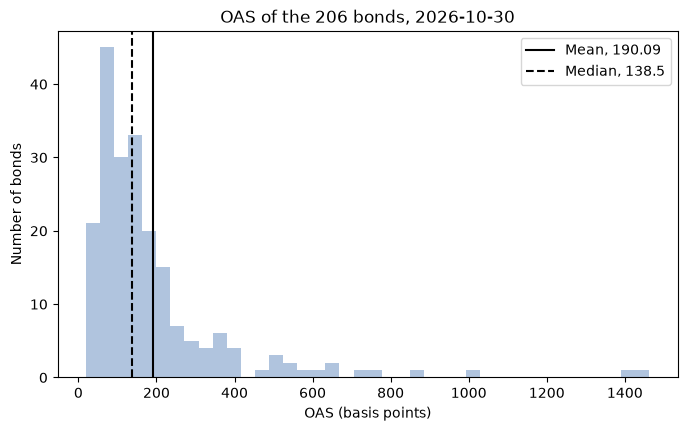

In [53]:
oas_mean = book['oas'].mean()
oas_median = book['oas'].median()

answer_6_1 = (book['oas'] > oas_mean).sum()
print('Bonds with an OAS above the mean:', answer_6_1, 'of', len(book))

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(book['oas'], bins=40, color='lightsteelblue')

# axvline() draws a vertical line
ax.axvline(oas_mean, color='black', label='Mean, ' + str(round(oas_mean, 2)))
ax.axvline(oas_median, color='black', linestyle='--', label='Median, ' + str(oas_median))

ax.legend()
ax.set_title('OAS of the 206 bonds, 2026-10-30')
ax.set_xlabel('OAS (basis points)')
ax.set_ylabel('Number of bonds')

plt.show()

* The crowd is on the left, below about 300 basis points, and a thin tail runs out to 1,463.
* 61 of the 206 bonds are above the mean of 190.09. If the column were even, about half would be. The tail pulls the mean up past most of the bonds.

In [54]:
check('Question 6.1', answer_6_1, 61)

Question 6.1: correct


### 6.2 The IQR rule

Q. Apply the IQR rule to the OAS. Print the two quartiles, the IQR, and the two limits, and draw a box plot of the column. Store the upper limit in **answer_6_2a** and the number of bonds above it in **answer_6_2b**.

First quartile: 81.5  third quartile: 208.75  IQR: 127.25
Lower limit: -109.375  upper limit: 399.625
Bonds below the lower limit: 0
Bonds above the upper limit: 18


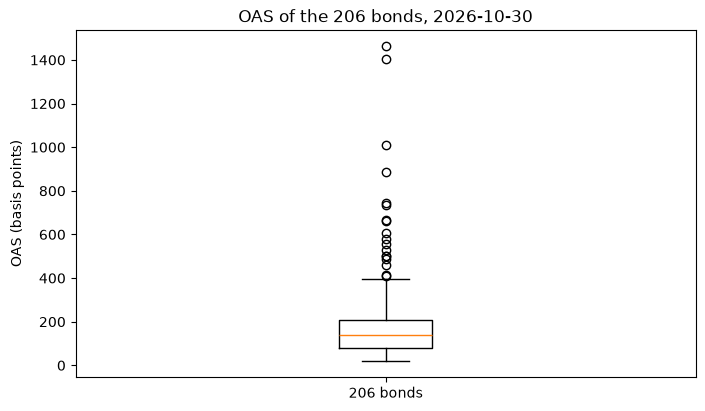

In [55]:
# the quartiles, the IQR, and the limits one and a half IQRs beyond each quartile
q1 = book['oas'].quantile(0.25)
q3 = book['oas'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

wide = book['oas'] > upper_limit

answer_6_2a = upper_limit
answer_6_2b = wide.sum()

print('First quartile:', q1, ' third quartile:', q3, ' IQR:', iqr)
print('Lower limit:', lower_limit, ' upper limit:', upper_limit)
print('Bonds below the lower limit:', (book['oas'] < lower_limit).sum())
print('Bonds above the upper limit:', answer_6_2b)

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() takes one column. tick_labels= names the box.
ax.boxplot(book['oas'], tick_labels=['206 bonds'])

ax.set_title('OAS of the 206 bonds, 2026-10-30')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The middle half of the bonds lies between 81.5 and 208.75 basis points, an IQR of 127.25. The upper limit is 399.625.
* 18 bonds are above it, the circles on the chart. The lower limit is -109.375, below zero, and nothing is under it.
* In Excel: `=QUARTILE.INC(M2:M207, 3) + 1.5 * (QUARTILE.INC(M2:M207, 3) - QUARTILE.INC(M2:M207, 1))` returns the upper limit, 399.625.

In [56]:
check('Question 6.2 upper limit', answer_6_2a, 399.625)
check('Question 6.2 bonds flagged', answer_6_2b, 18)

Question 6.2 upper limit: correct
Question 6.2 bonds flagged: correct


### 6.3 Errors or real bonds?

Q. Show the flagged bonds, widest first, with their rating, coupon, price, yield, and OAS. Are they errors or real bonds? Give the evidence from the other columns.

**Expected decision:** a row is corrected if it is an error and the right value is known, flagged if it is an error and the right value is not known, and kept if it is real. No row is deleted for being far away.

Store the flagged bonds' share of the book's market value, in percent rounded to 2 decimal places, in **answer_6_3**.

In [57]:
answer_6_3 = round(book.loc[wide, 'market_value'].sum() / book['market_value'].sum() * 100, 2)
print('Market value of the flagged bonds:', book.loc[wide, 'market_value'].sum(), 'dollars')
print('Share of the book:', answer_6_3, 'percent')
print('Scores of the flagged bonds: from', book.loc[wide, 'score'].min(), 'to', book.loc[wide, 'score'].max())

# the yield less the OAS is roughly the Treasury yield the bond is measured against
base = book['yield_pct'] - book['oas'] / 100
print('Yield less OAS, flagged bonds: from', round(base[wide].min(), 3), 'to', round(base[wide].max(), 3), 'percent')
print('Yield less OAS, other bonds:   from', round(base[~wide].min(), 3), 'to', round(base[~wide].max(), 3), 'percent')

book.loc[wide, ['cusip', 'ticker', 'rating', 'coupon', 'price', 'yield_pct', 'oas']].sort_values('oas', ascending=False)

Market value of the flagged bonds: 38858755.0 dollars
Share of the book: 7.62 percent
Scores of the flagged bonds: from 14 to 18
Yield less OAS, flagged bonds: from 3.731 to 4.584 percent
Yield less OAS, other bonds:   from 3.68 to 4.585 percent


,cusip,ticker,rating,coupon,price,yield_pct,oas
68,99069RAC4,FESR,CCC+,10.750,88.780,18.415,1463
17,99009JAA9,CLDB,B,9.500,63.522,18.300,1403
135,99038MAF6,PRAN,CCC+,11.000,75.387,14.664,1008
134,99038MAE9,PRAN,CCC+,10.875,88.883,13.116,884
115,99066OAD2,NEVN,B-,10.625,92.637,11.826,744
133,99038MAH2,PRAN,CCC+,11.000,99.320,11.272,736
114,99066OAB6,NEVN,B-,11.000,99.844,11.021,666
74,99088KAH5,GALX,B-,9.250,88.521,11.021,662
197,99036KAA3,XANL,CCC,10.625,101.346,10.389,607
69,99069RAD2,FESR,CCC+,8.875,89.803,10.259,580


* All 18 have a score from 14 to 18, which is B+ or lower: every one is High Yield. The widest are FESR at 1,463 basis points and CLDB at 1,403, with yields of 18.415 and 18.3 percent.
* The columns tell one story. A low rating, a wide spread, a high yield, and for most of them a high coupon or a low price.
* The yield less the OAS of the 18 runs from 3.731 to 4.584 percent, inside the band of 3.68 to 4.585 percent that the other 188 bonds occupy. The wrong prices of question 3.7 broke a relationship between columns. These bonds keep every one.

**Decision 7.** Keep all 18. They are real bonds with wide spreads, and they stay in every number. They are 38,858,755.0 dollars of market value, 7.62 percent of the book.

* Two of the 18 were corrected earlier in another column: XANL `99036KAA3` had a price in the wrong units and SKEN `99046UAD3` the wrong maturity. A bond can have an error in one column and a real extreme in another, and each column is judged on its own evidence.

In [58]:
check('Question 6.3', answer_6_3, 7.62)

Question 6.3: correct


### 6.4 The distribution of the price

Q. Draw a histogram of the clean price. How many bonds are priced below 100? Store the count in **answer_6_4**. Show the bond with the lowest price and the bond with the highest, and say whether either is an error.

Bonds priced below 100: 114  at 100 or above: 92


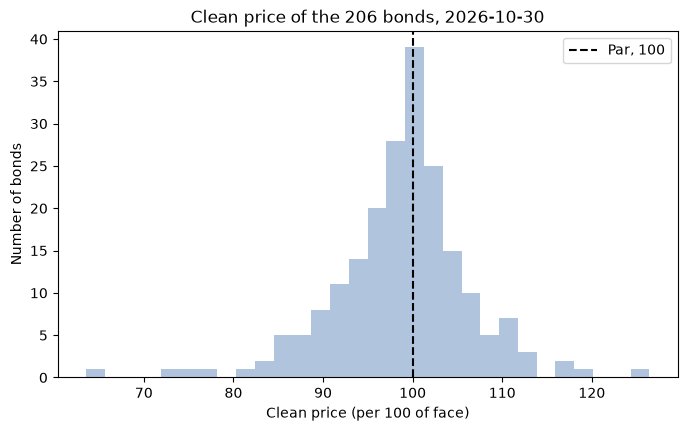

,cusip,ticker,rating,coupon,maturity,price,yield_pct,oas
17,99009JAA9,CLDB,B,9.50,2034-12-06,63.522,18.300,1403
192,99122SAE3,WYXE,BBB+,7.25,2056-07-24,126.427,5.445,86


In [59]:
answer_6_4 = (book['price'] < 100).sum()
print('Bonds priced below 100:', answer_6_4, ' at 100 or above:', (book['price'] >= 100).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(book['price'], bins=30, color='lightsteelblue')

# a line at par
ax.axvline(100, color='black', linestyle='--', label='Par, 100')

ax.legend()
ax.set_title('Clean price of the 206 bonds, 2026-10-30')
ax.set_xlabel('Clean price (per 100 of face)')
ax.set_ylabel('Number of bonds')

plt.show()

# idxmin() and idxmax() return the row labels of the lowest and the highest price
book.loc[[book['price'].idxmin(), book['price'].idxmax()], ['cusip', 'ticker', 'rating', 'coupon', 'maturity', 'price', 'yield_pct', 'oas']]

* 114 bonds are priced below 100 and 92 at 100 or above. The prices crowd around par, with a tail on the left, the negative skew of question 5.3.
* The lowest price is 63.522, for CLDB `99009JAA9`, a B bond with a 9.5 percent coupon, a yield of 18.3 percent, and an OAS of 1,403 basis points. It is one of the 18 wide bonds: a low price and a wide spread are the same fact seen twice.
* The highest price is 126.427, for WYXE `99122SAE3`, a BBB+ bond with a 7.25 percent coupon that matures in 2056 and yields 5.445 percent: a long bond with a coupon well above its yield.
* Neither is an error. Both tie out to their market value in question 3.8.

In [60]:
check('Question 6.4', answer_6_4, 114)

Question 6.4: correct


### 6.5 The size of the positions

Q. Draw a histogram of the market value of the positions, in millions of dollars. Which is the largest position, and what share of the book is it? Store that share, in percent rounded to 2 decimal places, in **answer_6_5**. Does the IQR rule flag any position as large?

Smallest position: 0.21 million dollars
Largest position: 5.44 million dollars, 1.07 percent of the book
Median position: 2.33  mean: 2.48 million dollars
IQR upper limit: 7.37 million dollars. Positions above it: 0


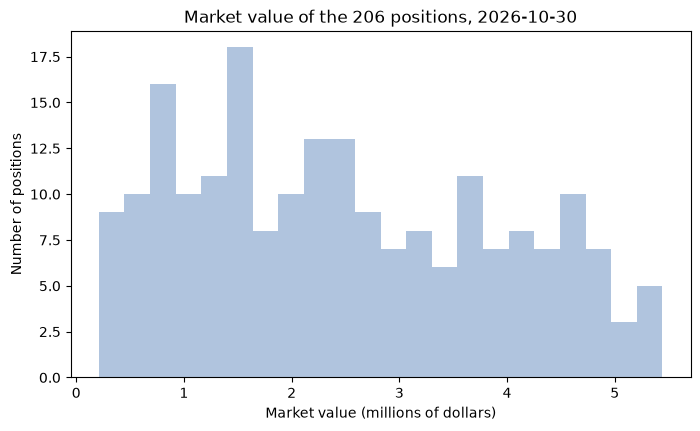

,cusip,ticker,issuer,par_held,market_value
61,99021VAC2,FESA,Feskundra Systems,5000000,5442600.0
105,99076YAC0,LORN,Lorvebran Paper,4750000,5423550.0
183,99024YAE9,VYRE,Vyrerone Metals,4750000,5382747.5


In [61]:
# market value in millions of dollars
value_mm = book['market_value'] / 1_000_000

answer_6_5 = round(book['market_value'].max() / book['market_value'].sum() * 100, 2)
print('Smallest position:', round(value_mm.min(), 2), 'million dollars')
print('Largest position:', round(value_mm.max(), 2), 'million dollars,', answer_6_5, 'percent of the book')
print('Median position:', round(value_mm.median(), 2), ' mean:', round(value_mm.mean(), 2), 'million dollars')

# the IQR upper limit for position size
size_limit = value_mm.quantile(0.75) + 1.5 * (value_mm.quantile(0.75) - value_mm.quantile(0.25))
print('IQR upper limit:', round(size_limit, 2), 'million dollars. Positions above it:', (value_mm > size_limit).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(value_mm, bins=22, color='lightsteelblue')

ax.set_title('Market value of the 206 positions, 2026-10-30')
ax.set_xlabel('Market value (millions of dollars)')
ax.set_ylabel('Number of positions')

plt.show()

# nlargest(n, column) gives the n rows with the largest values
book.nlargest(3, 'market_value')[['cusip', 'ticker', 'issuer', 'par_held', 'market_value']]

* Positions run from 0.21 to 5.44 million dollars. The median is 2.33 million and the mean 2.48 million, close together, as the skew of 0.28 said.
* The largest position is FESA `99021VAC2`, 5,442,600 dollars on 5,000,000 of face, which is 1.07 percent of the book. The next two are 5,423,550 and 5,382,747.5.
* The IQR upper limit is 7.37 million dollars and no position is above it. By position size the book has no outlier.

In [62]:
check('Question 6.5', answer_6_5, 1.07)

Question 6.5: correct


## 7 Two or more columns

### 7.1 Correlations

Q. Produce the correlation table of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `score`, rounded to 2 decimal places, and draw it as a heatmap with the number in each cell. Store the correlation of OAS and score, rounded to 2 decimal places, in **answer_7_1**.

A good answer names the strongest pair, a pair near zero, and says what the sign of the OAS and score figure means given how the score is built.

           coupon  price  yield_pct   oas  duration  score
coupon       1.00   0.25       0.76  0.76     -0.05   0.69
price        0.25   1.00      -0.35 -0.33     -0.17  -0.19
yield_pct    0.76  -0.35       1.00  0.99      0.01   0.75
oas          0.76  -0.33       0.99  1.00     -0.11   0.76
duration    -0.05  -0.17       0.01 -0.11      1.00  -0.12
score        0.69  -0.19       0.75  0.76     -0.12   1.00
Correlation of OAS and score: 0.76


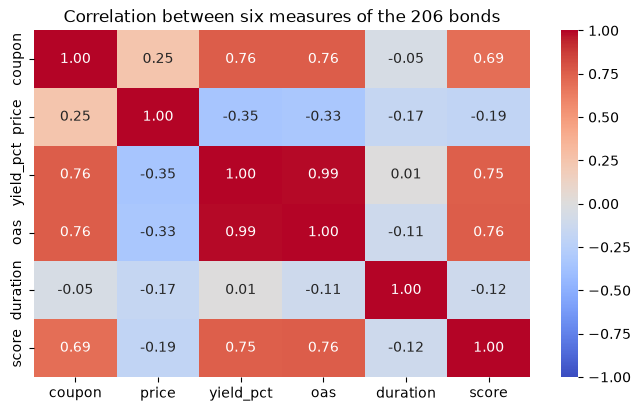

In [63]:
# corr() on a table gives the correlation of every pair of its columns
corr_table = book[['coupon', 'price', 'yield_pct', 'oas', 'duration', 'score']].corr()

answer_7_1 = round(corr_table.loc['oas', 'score'], 2)
print(corr_table.round(2))
print('Correlation of OAS and score:', answer_7_1)

fig, ax = plt.subplots(figsize=(8, 4.5))

# annot=True writes the number in each cell. vmin and vmax fix the ends of the colour scale, so 0 is in the middle.
sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation between six measures of the 206 bonds')

plt.show()

* The strongest pair is yield and OAS, 0.99: across one file on one date they are almost one column.
* OAS and score have a correlation of 0.76. The score rises as the rating falls, so a positive figure says that lower-rated bonds in this file have wider spreads. The coupon has 0.76 with the OAS and 0.69 with the score.
* Duration is near zero against every other column: -0.11 with the OAS and 0.01 with the yield. Question 7.2 looks inside that figure.
* Price is -0.35 with the yield and -0.33 with the OAS.

In [64]:
check('Question 7.1', answer_7_1, 0.76)

Question 7.1: correct


### 7.2 OAS against duration, by grade

Q. Draw a scatter plot of OAS against duration, with the two grades in different colours. Then work out the correlation of duration and yield for the whole book and within each grade. Store the Investment Grade figure, rounded to 2 decimal places, in **answer_7_2**.

A good answer says what the whole-book figure hides.

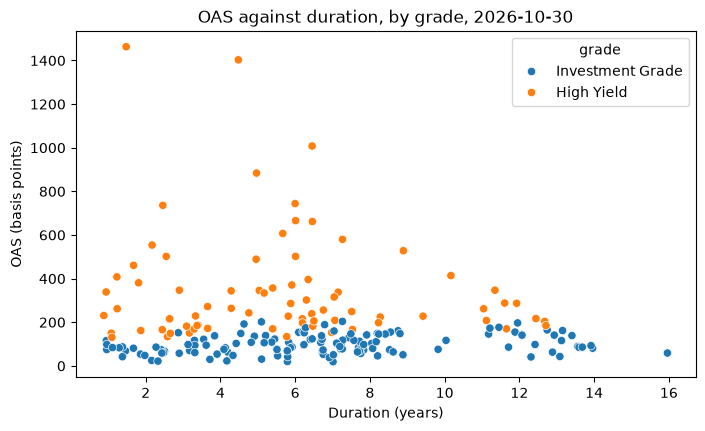

All 206 bonds: 0.01
Investment Grade - 130 bonds: 0.61
High Yield - 76 bonds: -0.01


In [65]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# hue= names the column that sets the colour of each point
sns.scatterplot(data=book, x='duration', y='oas', hue='grade', ax=ax)

ax.set_title('OAS against duration, by grade, 2026-10-30')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('OAS (basis points)')

plt.show()

print('All 206 bonds:', round(book['duration'].corr(book['yield_pct']), 2))

# the same correlation on the bonds of one grade at a time
for grade in ['Investment Grade', 'High Yield']:
    part = book[book['grade'] == grade]
    print(grade, '-', len(part), 'bonds:', round(part['duration'].corr(part['yield_pct']), 2))

investment_grade = book[book['grade'] == 'Investment Grade']
answer_7_2 = round(investment_grade['duration'].corr(investment_grade['yield_pct']), 2)

* On the chart the Investment Grade bonds lie in a flat band along the bottom, at every duration. The High Yield bonds are spread above them, from about 130 to 1,463 basis points, and most of the widest have a duration under 7 years.
* Duration and yield have a correlation of 0.01 over the whole book, 0.61 across the 130 Investment Grade bonds, and -0.01 across the 76 High Yield bonds.
* The whole-book figure hides a clear tilt within Investment Grade, where the longer bonds in this file have the higher yields. Two groups with different patterns, put in one cloud, show no pattern.
* This describes one invented file on one date. It is not a statement about what any bond should yield.

In [66]:
check('Question 7.2', answer_7_2, 0.61)

Question 7.2: correct


### 7.3 OAS by rating bucket

Q. Show the number of bonds and the median, lowest, and highest OAS of each rating bucket, in credit order, and draw the median OAS by bucket as a bar chart. Store the median OAS of the BBB bucket in **answer_7_3**.

        count  median  min   max
bucket                          
AAA         3    20.0   19    23
AA          9    38.0   22    59
A          58    74.5   42   152
BBB        60   132.5   64   204
BB         50   211.5  131   381
B          20   437.5  229  1403
CCC         6   810.0  580  1463


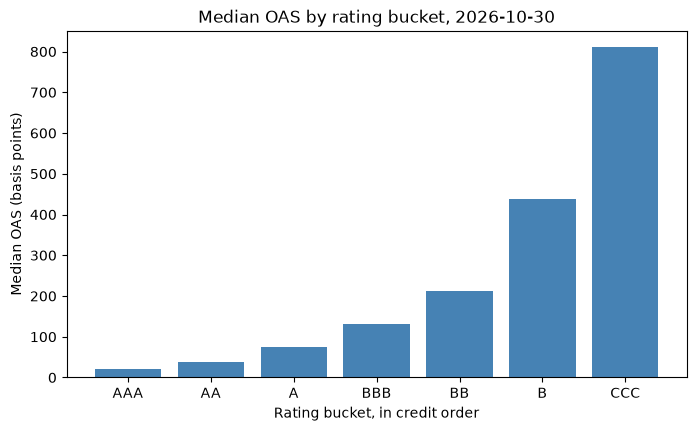

In [67]:
# the buckets in credit order, from the rating scale sorted by score
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

# four summaries of the OAS for each bucket, put in credit order with .loc
by_bucket = book.groupby('bucket')['oas'].agg(['count', 'median', 'min', 'max']).loc[bucket_order]
print(by_bucket)

answer_7_3 = by_bucket.loc['BBB', 'median']

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(by_bucket.index, by_bucket['median'], color='steelblue')

ax.set_title('Median OAS by rating bucket, 2026-10-30')
ax.set_xlabel('Rating bucket, in credit order')
ax.set_ylabel('Median OAS (basis points)')

plt.show()

* The median OAS rises at every step down the scale: 20 basis points for AAA, 38 for AA, 74.5 for A, 132.5 for BBB, 211.5 for BB, 437.5 for B, and 810 for CCC.
* The steps get larger. From A to BBB is 58 basis points, and from B to CCC is 372.5.
* The ranges overlap. The BBB bonds run from 64 to 204 basis points and the BB bonds from 131 to 381, so the widest BBB bond is wider than the tightest BB bond.
* The CCC median is over 6 bonds and the AAA median over 3. A median of so few bonds describes those bonds and little else.

In [68]:
check('Question 7.3', answer_7_3, 132.5)

Question 7.3: correct


### 7.4 OAS by grade

Q. Compare the OAS of the two grades with a box plot, one box for each grade. Print the number of bonds and the median of each. Store the High Yield median less the Investment Grade median in **answer_7_4**.

Investment Grade - bonds: 130  median: 89.0  mean: 98.45  widest: 204
High Yield       - bonds: 76  median: 259.0  mean: 346.86  widest: 1463
High Yield median less Investment Grade median: 170.0 basis points


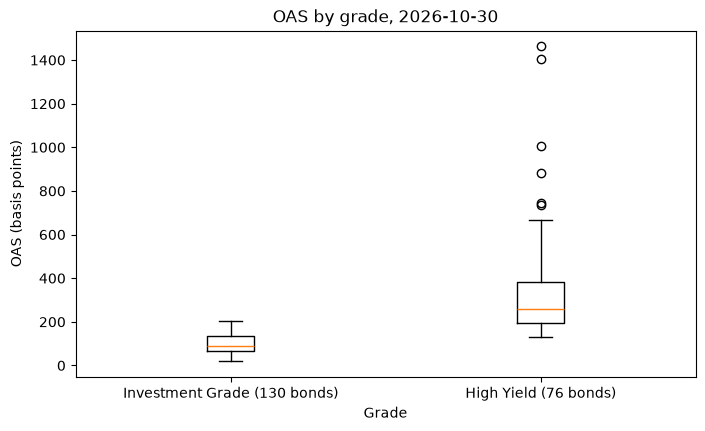

In [69]:
# the OAS of each grade
ig_oas = book.loc[book['grade'] == 'Investment Grade', 'oas']
hy_oas = book.loc[book['grade'] == 'High Yield', 'oas']

print('Investment Grade - bonds:', len(ig_oas), ' median:', ig_oas.median(), ' mean:', round(ig_oas.mean(), 2), ' widest:', ig_oas.max())
print('High Yield       - bonds:', len(hy_oas), ' median:', hy_oas.median(), ' mean:', round(hy_oas.mean(), 2), ' widest:', hy_oas.max())

answer_7_4 = hy_oas.median() - ig_oas.median()
print('High Yield median less Investment Grade median:', answer_7_4, 'basis points')

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() draws one box for each group in the list. tick_labels= names the boxes.
ax.boxplot([ig_oas, hy_oas], tick_labels=['Investment Grade (130 bonds)', 'High Yield (76 bonds)'])

ax.set_title('OAS by grade, 2026-10-30')
ax.set_xlabel('Grade')
ax.set_ylabel('OAS (basis points)')

plt.show()

* The median OAS is 89.0 basis points for the 130 Investment Grade bonds and 259.0 for the 76 High Yield bonds, a difference of 170.0.
* The means are further apart, 98.45 and 346.86. The Investment Grade mean is close to its median, and the High Yield mean is 87.86 above its median: the tail of the whole book is the tail of the High Yield bonds.
* The widest Investment Grade bond is at 204 basis points, below the High Yield median. The Investment Grade box is short and flat beside the High Yield box, and the High Yield box has circles above its whisker within its own group.

In [70]:
check('Question 7.4', answer_7_4, 170.0)

Question 7.4: correct


### 7.5 Sector by grade

Q. Build a pivot table of market value, in millions of dollars, with the sectors down the side and the two grades across the top, and draw it as a heatmap with the number in each cell. Check that the cells add up to the market value of the book. Store the name of the sector with the most High Yield market value in **answer_7_5**.

grade           Investment Grade  High Yield
sector                                      
Consumer                   34.92       17.98
Energy                     32.13        7.21
Financials                 49.98       19.98
Health Care                23.58       12.15
Industrials                33.05       17.24
Materials                  36.18       36.93
Technology                 24.92       10.79
Telecom                    34.69       30.56
Transportation             38.97       21.06
Utilities                  23.24        4.35
Sum of the cells: 509.93 million dollars
Sector with the most High Yield market value: Materials


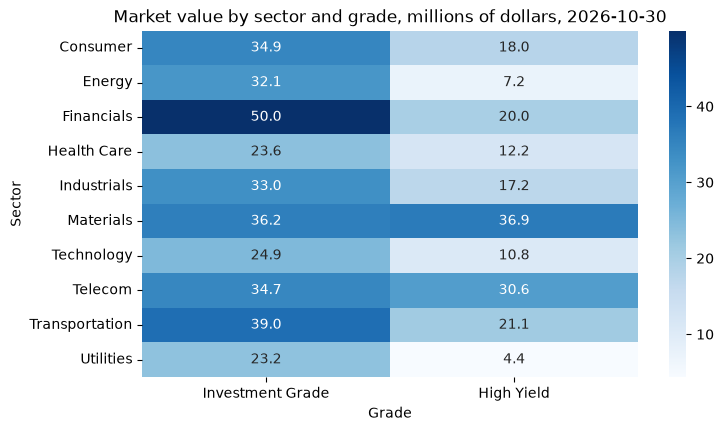

In [71]:
# sectors down the side, grades across the top, the sum of market value in each cell, in millions of dollars
sector_by_grade = pd.pivot_table(book, values='market_value', index='sector', columns='grade',
                                 aggfunc='sum', fill_value=0) / 1_000_000

# Investment Grade first
sector_by_grade = sector_by_grade[['Investment Grade', 'High Yield']]
print(sector_by_grade.round(2))
print('Sum of the cells:', round(sector_by_grade.sum().sum(), 2), 'million dollars')

answer_7_5 = sector_by_grade['High Yield'].idxmax()
print('Sector with the most High Yield market value:', answer_7_5)

fig, ax = plt.subplots(figsize=(8, 4.5))

# fmt='.1f' shows one decimal place. Blues runs from white for the lowest value to dark blue for the highest.
sns.heatmap(sector_by_grade, annot=True, fmt='.1f', cmap='Blues', ax=ax)

ax.set_title('Market value by sector and grade, millions of dollars, 2026-10-30')
ax.set_xlabel('Grade')
ax.set_ylabel('Sector')

plt.show()

* The 20 cells add up to 509.93 million dollars, the market value of the book.
* The largest cell is Investment Grade Financials, 49.98 million dollars. The smallest is High Yield Utilities, 4.35 million.
* Materials has the most High Yield market value, 36.93 million, against 36.18 million of Investment Grade. It is the only sector where the High Yield figure is the larger of the two. Telecom is the next closest, with 30.56 against 34.69.
* In Energy and Utilities the High Yield figure is under a quarter of the Investment Grade one: 7.21 against 32.13, and 4.35 against 23.24.

In [72]:
check('Question 7.5', answer_7_5, 'Materials')

Question 7.5: correct


## 8 The desk's questions

These are the questions the portfolio manager will ask. Each answer is a table or a figure with its unit. Weights are percent of the book's market value unless the question says otherwise.

### 8.1 Value and weight by sector

Q. Add a `weight_pct` column to `book`: each bond's market value as a percent of the book's. Then show, for each sector, the number of bonds, the market value, and the weight, largest weight first. Check that the weights add up to 100. Store the weight of the largest sector, rounded to 2 decimal places, in **answer_8_1**.

In [73]:
total_value = book['market_value'].sum()

# each bond's share of the book, in percent
book['weight_pct'] = book['market_value'] / total_value * 100
print('Sum of the weights:', round(book['weight_pct'].sum(), 2))

# one row per sector: its bonds, their market value, and their weight
by_sector = book.groupby('sector').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
)
by_sector = by_sector.sort_values('weight_pct', ascending=False)
print(by_sector.round(2))

answer_8_1 = round(by_sector['weight_pct'].max(), 2)
print('Three largest sectors together:', round(by_sector['weight_pct'].head(3).sum(), 2), 'percent')

Sum of the weights: 100.0
                bonds  market_value  weight_pct
sector                                         
Materials          27    73113917.5       14.34
Financials         27    69958000.0       13.72
Telecom            25    65251515.0       12.80
Transportation     22    60036355.0       11.77
Consumer           24    52902217.5       10.37
Industrials        19    50287460.0        9.86
Energy             16    39345555.0        7.72
Health Care        18    35733470.0        7.01
Technology         14    35708670.0        7.00
Utilities          14    27591317.5        5.41
Three largest sectors together: 40.85 percent


* Materials is the largest sector, with 73,113,917.5 dollars in 27 bonds, 14.34 percent of the book. Financials is next with 13.72 percent, then Telecom with 12.80 and Transportation with 11.77.
* The three largest sectors together are 40.85 percent. The smallest is Utilities, 5.41 percent in 14 bonds.
* The order by weight is not the order by count: Technology and Utilities both have 14 bonds, with weights of 7.00 and 5.41 percent.
* In Excel: `=SUMIF(E2:E207, "Materials", S2:S207) / SUM(S2:S207) * 100` on the corrected sheet, or a pivot table with `sector` in Rows and Sum of `market_value` in Values, shown as a percent of the column total.

In [74]:
check('Question 8.1', answer_8_1, 14.34)

Question 8.1: correct


### 8.2 Value and weight by rating bucket and grade

Q. Show the same three figures for each rating bucket, in credit order, and the weight of each grade. Store the High Yield weight, rounded to 2 decimal places, in **answer_8_2**.

In [75]:
by_bucket_value = book.groupby('bucket').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
).loc[bucket_order]
print(by_bucket_value.round(2))

by_grade = book.groupby('grade')['weight_pct'].sum()
print(by_grade.round(2))

answer_8_2 = round(by_grade.loc['High Yield'], 2)

        bonds  market_value  weight_pct
bucket                                 
AAA         3    12791580.0        2.51
AA          9    17032815.0        3.34
A          58   154371405.0       30.27
BBB        60   147458980.0       28.92
BB         50   117426757.5       23.03
B          20    46050397.5        9.03
CCC         6    14796542.5        2.90
grade
High Yield          34.96
Investment Grade    65.04
Name: weight_pct, dtype: float64


* The A bucket is the largest by weight, 30.27 percent, ahead of BBB with 28.92, though BBB has more bonds, 60 against 58. BB is 23.03 percent.
* The two ends are small: AAA 2.51 percent and AA 3.34, B 9.03 and CCC 2.90.
* Investment Grade is 65.04 percent of the book and High Yield 34.96 percent. By count High Yield is 76 of 206 bonds, which is 36.89 percent, a little more than its weight.

In [76]:
check('Question 8.2', answer_8_2, 34.96)

Question 8.2: correct


### 8.3 The ten largest issuers

Q. How many issuers are in the book? Which ten have the most market value, and what share of the book are the ten together? Store that share, in percent rounded to 2 decimal places, in **answer_8_3**.

In [77]:
print('Issuers in the book:', book['issuer'].nunique())

# one row per issuer: its bonds added together
by_issuer = book.groupby('issuer').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    weight_pct=('weight_pct', 'sum'),
)
top_ten = by_issuer.nlargest(10, 'market_value')
print(top_ten.round(2))

answer_8_3 = round(top_ten['weight_pct'].sum(), 2)
print('The ten together:', answer_8_3, 'percent of the book')
print('Ten issuers out of', book['issuer'].nunique(), 'is', round(10 / book['issuer'].nunique() * 100, 2), 'percent of the issuers')

Issuers in the book: 113
                     bonds  market_value  weight_pct
issuer                                              
Corvoquil Metals         4    14539015.0        2.85
Dralane Networks         3    12791580.0        2.51
Elverone Industrial      4    11372580.0        2.23
Heskundra Retail         3    11023215.0        2.16
Vraxorin Bancorp         3    10786540.0        2.12
Galvellix Paper          3    10359502.5        2.03
Grovostrin Freight       3    10080567.5        1.98
Lorvellix Energy         2     9999995.0        1.96
Krilellix Networks       3     9517337.5        1.87
Nevulex Health           5     8839500.0        1.73
The ten together: 21.44 percent of the book
Ten issuers out of 113 is 8.85 percent of the issuers


* 113 issuers. The largest is Corvoquil Metals, with 14,539,015 dollars in 4 bonds, 2.85 percent of the book. The second is Dralane Networks with 2.51 percent, and the tenth is Nevulex Health with 1.73.
* The ten together are 21.44 percent of the book. Ten issuers are 8.85 percent of the 113.
* An issuer is counted by adding its bonds. The largest single position was 1.07 percent in question 6.5, and the largest issuer is 2.85.
* All of these names are invented. The table says where the market value sits and nothing about any issuer.

In [78]:
check('Question 8.3', answer_8_3, 21.44)

Question 8.3: correct


### 8.4 Weighted averages

Q. What are the average coupon, OAS, duration, and rating score of the book, both simple and weighted by market value? Store the weighted average OAS, rounded to 1 decimal place, in **answer_8_4a**, and the weighted average duration, rounded to 2 decimal places, in **answer_8_4b**.

In [79]:
# the weighted average: the sum of value times market value, divided by the sum of market value
for column in ['coupon', 'oas', 'duration', 'score']:
    simple = book[column].mean()
    weighted = (book[column] * book['market_value']).sum() / total_value
    print(column, '- simple:', round(simple, 2), ' weighted by market value:', round(weighted, 2))

answer_8_4a = round((book['oas'] * book['market_value']).sum() / total_value, 1)
answer_8_4b = round((book['duration'] * book['market_value']).sum() / total_value, 2)

coupon - simple: 5.96  weighted by market value: 5.96
oas - simple: 190.09  weighted by market value: 181.3
duration - simple: 6.33  weighted by market value: 6.08
score - simple: 9.39  weighted by market value: 9.22


* Coupon: 5.96 percent simple and 5.96 weighted. Position size and coupon are not related in this book.
* OAS: 190.09 basis points simple and 181.3 weighted. Duration: 6.33 years simple and 6.08 weighted. In both the weighted figure is the lower one, so the larger positions are, on balance, in bonds with tighter spreads and shorter durations than the smaller positions.
* Rating score: 9.39 simple and 9.22 weighted. Both are between 9, which is BBB, and 10, which is BBB-.
* The portfolio manager's figures are the weighted ones. A simple average answers a question about the typical bond, and a weighted average answers a question about the typical dollar.
* In Excel: `=SUMPRODUCT(M2:M207, S2:S207) / SUM(S2:S207)` for the weighted OAS, with the OAS in column M and the market value in column S.

In [80]:
check('Question 8.4 weighted OAS', answer_8_4a, 181.3)
check('Question 8.4 weighted duration', answer_8_4b, 6.08)

Question 8.4 weighted OAS: correct
Question 8.4 weighted duration: correct


### 8.5 DTS by sector

Q. A bond's contribution to the DTS of the book is its weight, as a fraction of the book, times its DTS. The contributions of all the bonds add up to the DTS of the book. Add a `dts_contribution` column to `book`. Then show, for each sector, its weight, its contribution, and its share of the book's DTS in percent, largest contribution first. Show the same for the two grades. Store the DTS of the book, rounded to 1 decimal place, in **answer_8_5**.

In [81]:
# weight_pct is in percent, so divide by 100 for the fraction
book['dts_contribution'] = book['weight_pct'] / 100 * book['dts']

book_dts = book['dts_contribution'].sum()
answer_8_5 = round(book_dts, 1)
print('DTS of the book:', answer_8_5)

# for each sector: its weight, its contribution, and its share of the book's DTS
dts_by_sector = book.groupby('sector').agg(
    weight_pct=('weight_pct', 'sum'),
    dts_contribution=('dts_contribution', 'sum'),
)
dts_by_sector['share_of_dts_pct'] = dts_by_sector['dts_contribution'] / book_dts * 100
print(dts_by_sector.sort_values('dts_contribution', ascending=False).round(2))

# the same by grade
dts_by_grade = book.groupby('grade').agg(
    weight_pct=('weight_pct', 'sum'),
    dts_contribution=('dts_contribution', 'sum'),
)
dts_by_grade['share_of_dts_pct'] = dts_by_grade['dts_contribution'] / book_dts * 100
print(dts_by_grade.round(2))

DTS of the book: 1022.3
                weight_pct  dts_contribution  share_of_dts_pct
sector                                                        
Financials           13.72            149.22             14.60
Industrials           9.86            141.58             13.85
Consumer             10.37            138.27             13.52
Telecom              12.80            126.57             12.38
Materials            14.34            111.05             10.86
Transportation       11.77            109.66             10.73
Energy                7.72             82.70              8.09
Technology            7.00             60.55              5.92
Utilities             5.41             55.77              5.45
Health Care           7.01             46.97              4.59
                  weight_pct  dts_contribution  share_of_dts_pct
grade                                                           
High Yield             34.96            585.70             57.29
Investment Grade       65

* The DTS of the book is 1,022.3.
* Financials contributes the most, 149.22, which is 14.60 percent of the book's DTS on 13.72 percent of its weight. Industrials is second with 13.85 percent of the DTS on 9.86 percent of the weight, and Consumer third with 13.52 percent on 10.37.
* Materials is the largest sector by weight, 14.34 percent, and fifth by DTS, with 10.86 percent. Health Care is 7.01 percent of the weight and 4.59 percent of the DTS, the smallest share.
* By grade, High Yield is 34.96 percent of the weight and 57.29 percent of the DTS. Investment Grade is 65.04 percent of the weight and 42.71 percent of the DTS.
* A weight says where the dollars are. A DTS share says where the spread exposure is. The two tables rank the sectors differently, and both are descriptions of the book.

In [82]:
check('Question 8.5', answer_8_5, 1022.3)

Question 8.5: correct


### 8.6 Maturing within three years

Q. How many bonds mature within three years of the as-of date, and what share of the book are they? Count the years as the days from the as-of date to the maturity, divided by 365.25, as in notebook 10. Store the share, in percent rounded to 2 decimal places, in **answer_8_6**.

In [83]:
# a date minus a date is a length of time. .dt.days gives it as a number of days.
book['years_to_maturity'] = (book['maturity'] - book['as_of_date']).dt.days / 365.25
print('Shortest:', round(book['years_to_maturity'].min(), 2), ' longest:', round(book['years_to_maturity'].max(), 2), 'years')

within_three = book['years_to_maturity'] <= 3

answer_8_6 = round(book.loc[within_three, 'weight_pct'].sum(), 2)
print('Bonds maturing within three years:', within_three.sum())
print('Their market value:', book.loc[within_three, 'market_value'].sum(), 'dollars')
print('Share of the book:', answer_8_6, 'percent')

Shortest: 0.92  longest: 29.73 years
Bonds maturing within three years: 35
Their market value: 94510505.0 dollars
Share of the book: 18.53 percent


* The bonds have from 0.92 to 29.73 years left.
* 35 bonds mature within three years, with 94,510,505.0 dollars of market value, 18.53 percent of the book.
* The count rests on the maturity column, and one maturity was corrected in question 3.8. Left at 2019, that row would have had a negative number of years left: the shortest figure printed above would have been below zero, which is one more way the error could have been found.

In [84]:
check('Question 8.6', answer_8_6, 18.53)

Question 8.6: correct


### 8.7 The book against its benchmark, by sector

The benchmark file gives each of its 821 bonds a `weight_pct`. Adding those weights within a sector gives the benchmark's sector weight. The difference, **book weight less benchmark weight**, is in percentage points.

A positive difference is called an **overweight** and a negative one an **underweight**. In this project the two words are arithmetic and nothing more: they name the sign of a subtraction. They do not say that a weight is too high or too low, and they are not a view on any sector.

The benchmark file is the September file and the book is October's. Say so wherever the comparison is reported.

Q. Show, for each sector, the book weight, the benchmark weight, and the difference, sorted by the difference. Draw the differences as a horizontal bar chart with a line at zero. Store the name of the sector with the largest positive difference in **answer_8_7a** and that difference, rounded to 2 decimal places, in **answer_8_7b**.

A good chart here says in its title which way the subtraction runs.

                book_pct  benchmark_pct  difference
sector                                             
Utilities           5.41          11.50       -6.09
Energy              7.72          11.06       -3.35
Health Care         7.01           8.04       -1.03
Industrials         9.86           9.62        0.24
Transportation     11.77          10.74        1.03
Telecom            12.80          11.70        1.09
Consumer           10.37           9.14        1.24
Technology          7.00           5.40        1.61
Materials          14.34          11.87        2.47
Financials         13.72          10.93        2.79
Sum of the book weights: 100.0  sum of the benchmark weights: 100.0
Negative differences: 3 adding up to -10.47
Positive differences: 7 adding up to 10.47
Largest positive difference: Financials 2.79 percentage points


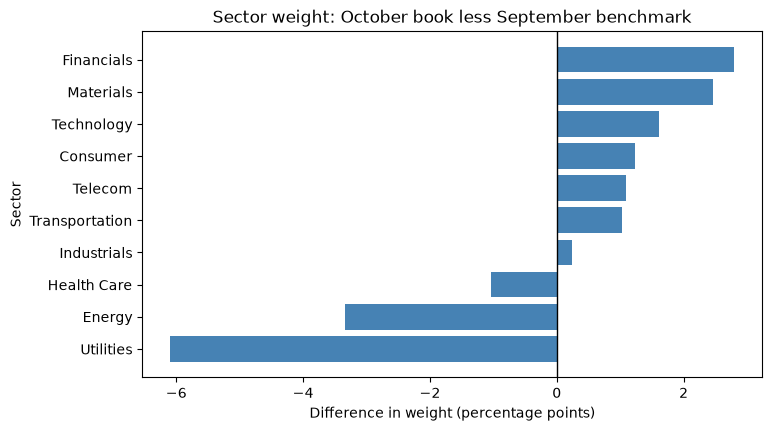

In [85]:
# the weight of each sector in the book and in the benchmark. pandas lines the two up by sector name.
sector_weights = pd.DataFrame({
    'book_pct': book.groupby('sector')['weight_pct'].sum(),
    'benchmark_pct': benchmark.groupby('sector')['weight_pct'].sum(),
})
sector_weights['difference'] = sector_weights['book_pct'] - sector_weights['benchmark_pct']

# smallest difference first, so that the largest is at the top of a horizontal bar chart
sector_weights = sector_weights.sort_values('difference')
print(sector_weights.round(2))
print('Sum of the book weights:', round(sector_weights['book_pct'].sum(), 2),
      ' sum of the benchmark weights:', round(sector_weights['benchmark_pct'].sum(), 2))

# the negative differences added together, and the positive ones
negative = sector_weights.loc[sector_weights['difference'] < 0, 'difference']
positive = sector_weights.loc[sector_weights['difference'] > 0, 'difference']
print('Negative differences:', len(negative), 'adding up to', round(negative.sum(), 2))
print('Positive differences:', len(positive), 'adding up to', round(positive.sum(), 2))

answer_8_7a = sector_weights['difference'].idxmax()
answer_8_7b = round(sector_weights['difference'].max(), 2)
print('Largest positive difference:', answer_8_7a, answer_8_7b, 'percentage points')

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.barh(sector_weights.index, sector_weights['difference'], color='steelblue')

# axvline() draws the zero line: bars to its left are sectors with less weight in the book than in the benchmark
ax.axvline(0, color='black', linewidth=1)

ax.set_title('Sector weight: October book less September benchmark')
ax.set_xlabel('Difference in weight (percentage points)')
ax.set_ylabel('Sector')

plt.show()

* Seven sectors have a positive difference and three a negative one. Both sets of weights add up to 100.0, so the positive and the negative differences cancel.
* The largest positive difference is Financials, 2.79 percentage points: 13.72 percent of the book against 10.93 percent of the benchmark. Materials is next with 2.47.
* The largest negative difference is Utilities, -6.09 percentage points: 5.41 percent of the book against 11.50 percent of the benchmark. Energy is -3.35 and Health Care -1.03.
* The Utilities bar is the longest on the chart by a wide margin: 6.09 against 3.35 for the next longest. Three negative differences that add up to -10.47 are offset by seven positive ones that add up to 10.47, none above 2.79.
* The book is as of 2026-10-30 and the benchmark as of 2026-09-30. The differences mix the desk's positions with one month of price changes in the book that the benchmark file does not have.

In [86]:
check('Question 8.7 sector', answer_8_7a, 'Financials')
check('Question 8.7 difference', answer_8_7b, 2.79)

Question 8.7 sector: correct
Question 8.7 difference: correct


### 8.8 The book against its benchmark, by rating bucket

Q. Make the same comparison by rating bucket, in credit order, and by grade. The benchmark needs the rating scale joined to it first. Draw the bucket differences as a bar chart with a line at zero and the buckets in credit order. Store the difference for the BBB bucket, rounded to 2 decimal places, in **answer_8_8**.

Benchmark rows before: 821  after: 821  with no bucket: 0
        book_pct  benchmark_pct  difference
bucket                                     
AAA         2.51           1.24        1.27
AA          3.34           3.62       -0.28
A          30.27          29.15        1.12
BBB        28.92          31.61       -2.69
BB         23.03          21.11        1.92
B           9.03          11.65       -2.62
CCC         2.90           1.62        1.28
                  book_pct  benchmark_pct  difference
grade                                                
High Yield           34.96          34.38        0.58
Investment Grade     65.04          65.62       -0.58


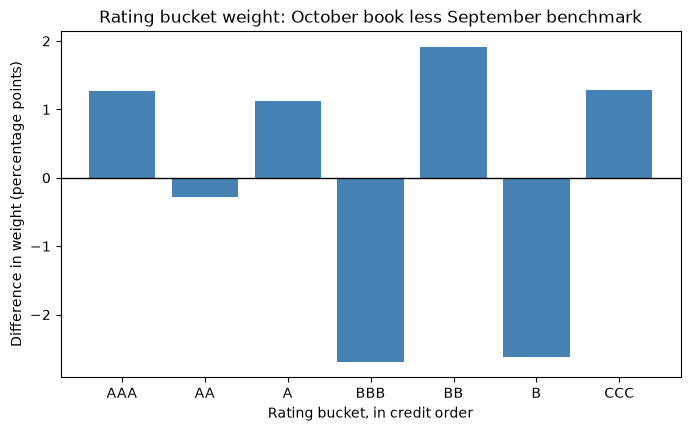

In [87]:
# the benchmark has ratings and no buckets, so look them up
benchmark_rated = pd.merge(benchmark, ratings, on='rating', how='left')
print('Benchmark rows before:', len(benchmark), ' after:', len(benchmark_rated),
      ' with no bucket:', benchmark_rated['bucket'].isna().sum())

bucket_weights = pd.DataFrame({
    'book_pct': book.groupby('bucket')['weight_pct'].sum(),
    'benchmark_pct': benchmark_rated.groupby('bucket')['weight_pct'].sum(),
}).loc[bucket_order]
bucket_weights['difference'] = bucket_weights['book_pct'] - bucket_weights['benchmark_pct']
print(bucket_weights.round(2))

grade_weights = pd.DataFrame({
    'book_pct': book.groupby('grade')['weight_pct'].sum(),
    'benchmark_pct': benchmark_rated.groupby('grade')['weight_pct'].sum(),
})
grade_weights['difference'] = grade_weights['book_pct'] - grade_weights['benchmark_pct']
print(grade_weights.round(2))

answer_8_8 = round(bucket_weights.loc['BBB', 'difference'], 2)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(bucket_weights.index, bucket_weights['difference'], color='steelblue')

# axhline() draws the zero line: bars below it are buckets with less weight in the book than in the benchmark
ax.axhline(0, color='black', linewidth=1)

ax.set_title('Rating bucket weight: October book less September benchmark')
ax.set_xlabel('Rating bucket, in credit order')
ax.set_ylabel('Difference in weight (percentage points)')

plt.show()

* The join kept all 821 benchmark bonds and every one has a bucket.
* The two largest differences are negative: BBB at -2.69 percentage points, 28.92 percent of the book against 31.61 of the benchmark, and B at -2.62, 9.03 against 11.65.
* The largest positive difference is BB, 1.92, then CCC with 1.28, AAA with 1.27, and A with 1.12. AA is -0.28.
* The signs alternate down the scale, so the grades come out close: High Yield is 34.96 percent of the book and 34.38 percent of the benchmark, a difference of 0.58 percentage points, and Investment Grade is -0.58.
* A difference of 0.58 by grade sits on top of bucket differences of up to 2.69. A comparison at one level of detail does not show what is underneath it.

In [88]:
check('Question 8.8', answer_8_8, -2.69)

Question 8.8: correct


### 8.9 The bonds that carry the most DTS

Q. Which ten bonds contribute the most to the DTS of the book? Show their CUSIP, ticker, rating, OAS, duration, DTS, weight, and contribution. Store the ten bonds' share of the book's DTS, in percent rounded to 1 decimal place, in **answer_8_9**, and print their combined weight beside it.

In [89]:
# the ten rows with the largest contributions
top_dts = book.nlargest(10, 'dts_contribution')

answer_8_9 = round(top_dts['dts_contribution'].sum() / book_dts * 100, 1)
print('Share of the book DTS in the ten bonds:', answer_8_9, 'percent')
print('Their weight in the book:', round(top_dts['weight_pct'].sum(), 2), 'percent')
print(top_dts['grade'].value_counts())

top_dts[['cusip', 'ticker', 'rating', 'oas', 'duration', 'dts', 'weight_pct', 'dts_contribution']].round(2)

Share of the book DTS in the ten bonds: 22.2 percent
Their weight in the book: 6.96 percent
grade
High Yield          9
Investment Grade    1
Name: count, dtype: int64


,cusip,ticker,rating,oas,duration,dts,weight_pct,dts_contribution
115,99066OAD2,NEVN,B-,744,6.00,4462.5,0.80,35.87
134,99038MAE9,PRAN,CCC+,884,4.97,4389.9,0.77,33.63
197,99036KAA3,XANL,CCC,607,5.67,3440.5,0.66,22.84
149,99046UAA9,SKEN,B+,371,5.91,2192.6,0.98,21.56
86,99004EAB3,HLVF,B+,414,10.17,4209.1,0.49,20.83
136,99145PAA0,PRAR,B-,489,4.96,2423.0,0.85,20.68
17,99009JAA9,CLDB,B,1403,4.48,6285.4,0.30,18.67
135,99038MAF6,PRAN,CCC+,1008,6.45,6504.6,0.27,17.80
39,99002CAB9,DNMR,BB+,170,11.65,1981.2,0.89,17.61
11,99033HAF2,CLAE,BBB-,155,11.88,1841.7,0.94,17.22


* The ten bonds carry 22.2 percent of the book's DTS on 6.96 percent of its weight.
* The largest contribution is 35.87, from NEVN `99066OAD2`, a B- bond with an OAS of 744 basis points, a duration of 6.0 years, and a weight of 0.80 percent. PRAN `99038MAE9` is second with 33.63.
* 9 of the ten are High Yield and 1 is Investment Grade: CLAE `99033HAF2`, rated BBB-, with an OAS of 155 basis points and a duration of 11.88 years. DTS is a product, and a bond reaches the list through a wide spread, a long duration, a large weight, or some of each.
* CLDB `99009JAA9` has the second highest DTS of any bond in the list, 6,285.4, and is seventh by contribution, because its weight is 0.30 percent.
* The table lists where the book's DTS sits on 2026-10-30. It is not a view on any of the ten bonds.

In [90]:
check('Question 8.9', answer_8_9, 22.2)

Question 8.9: correct


## 9 The conclusion

### 9.1 The written picture of the book

Q. Write the page for the portfolio manager, in a markdown cell, in 250 to 350 words. Use this outline:

1. **The book in five numbers.** The five figures a reader needs first, each with its unit.
2. **Concentrations.** Where the market value and the DTS sit: by sector, by grade, by issuer.
3. **Data quality.** Each problem found in the extract, in how many rows, and what was done. Say what was checked and found clean.
4. **Against the benchmark.** The differences in weight by sector and by rating bucket, as numbers, and the dates of the two files.
5. **Open items.** What the operations team needs to confirm or send.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-10-30. No sentence says that a bond, an issuer, or a sector is attractive or unattractive, what the desk should buy or sell, or what will happen next. Overweight and underweight, if you use them, mean a positive or a negative difference in weight and nothing else.

A good conclusion can be read without the notebook, has a number in almost every sentence, gives the unit of each number, and contains nothing that is not supported by a cell above it. There is no check cell for this question.

### 9.1 A model answer

**Month-end picture of the book, 2026-10-30.** All names are invented.

**The book in five numbers.** The book holds 206 bonds of 113 issuers with a market value of 509.93 million dollars on 507.25 million of face. Weighted by market value, the average OAS is 181.3 basis points, the average duration is 6.08 years, and the average rating score is 9.22, between BBB and BBB-.

**Concentrations.** Materials is the largest sector at 14.34 percent of market value, then Financials at 13.72 and Telecom at 12.80. Investment Grade is 65.04 percent and High Yield 34.96 percent. The ten largest issuers are 21.44 percent of the book and the largest position is 1.07 percent. The DTS of the book is 1,022.3. High Yield carries 57.29 percent of it, and the ten bonds with the largest contributions carry 22.2 percent on 6.96 percent of the weight.

**Data quality.** The extract had 209 rows against 206 in the cover note. 3 exact duplicate rows were removed. 9 sector names with the wrong case or a stray space were tidied, taking 19 sector values to 10. 2 face amounts with the wrong sign were made positive, 3 prices in the wrong units were corrected, and 1 maturity dated 2019 was replaced with the benchmark's 2029 date. 4 missing OAS values were worked out from DTS and spread duration. The corrected table matches all three control totals. Identifiers, ratings, and price dates were checked and are clean. 18 bonds flagged by the IQR rule on OAS are real and were kept.

**Against the benchmark.** The benchmark file is dated 2026-09-30. By sector, the largest positive difference in weight is Financials, 2.79 percentage points, and the largest negative is Utilities, -6.09. By rating bucket, BBB is -2.69 and BB is 1.92. High Yield is 0.58 points above the benchmark's 34.38 percent.

**Open items.** Operations to confirm the 6 corrected values and the 4 worked-out OAS values, and to say why 3 rows were sent twice. An October benchmark file is needed to compare the two on the same date.

## The closing reconciliation

The six decisions are applied once more, to a fresh copy of the extract in one cell, and the result is tested against the cover note and against `book`. The planted problems are listed in `data/project_answer_key.md` in the course repo.

In [91]:
# a fresh copy of the file as it arrived, with its dates read
final = raw.copy()
for column in ['as_of_date', 'maturity', 'price_date']:
    final[column] = pd.to_datetime(final[column], format='%Y-%m-%d')

# decision 1: remove the repeated rows
final = final.drop_duplicates().reset_index(drop=True)

# decision 2: tidy the sector names
final['sector'] = final['sector'].str.strip().str.title()

# decision 3: make the negative face positive
final['par_held'] = final['par_held'].abs()

# decision 4: put the prices back into per 100 of face
final.loc[final['price'] < 10, 'price'] = (final.loc[final['price'] < 10, 'price'] * 100).round(3)
final.loc[final['price'] > 1000, 'price'] = (final.loc[final['price'] > 1000, 'price'] / 100).round(3)

# decision 5: the maturity of the one bond, from the benchmark
final.loc[final['maturity'] <= final['as_of_date'], 'maturity'] = pd.Timestamp(benchmark_row['maturity'].iloc[0])

# decision 6: fill the missing OAS from DTS and spread duration
final['oas'] = final['oas'].fillna((final['dts'] / final['spread_duration']).round()).astype(int)

headline('As received', raw)
headline('As corrected', final)

print('Corrected less cover note:')
print('   bonds:', len(final) - expected_bonds)
print('   face:', final['par_held'].sum() - expected_face, 'dollars')
print('   market value:', round(final['market_value'].sum() - expected_value, 2), 'dollars')

# final.columns is the list of the 19 original columns. == compares the two tables cell by cell,
# and all() twice asks whether every cell of every column is True.
same = (final == book[final.columns]).all().all()
print('Same as book in all 19 columns and', len(final), 'rows:', same)

worked_out = final['par_held'] * (final['price'] + final['accrued']) / 100
print('Rows that do not tie out:', ((worked_out - final['market_value']).abs() > 1).sum())

As received
   rows: 209
   face: 507000000 dollars
   market value: 516229847.5 dollars
   mean OAS: 192.18 basis points
As corrected
   rows: 206
   face: 507250000 dollars
   market value: 509928477.5 dollars
   mean OAS: 190.09 basis points
Corrected less cover note:
   bonds: 0
   face: 0 dollars
   market value: 0.0 dollars
Same as book in all 19 columns and 206 rows: True
Rows that do not tie out: 0


* As received: 209 rows, 507,000,000 dollars of face, 516,229,847.5 dollars of market value, and a mean OAS of 192.18 basis points over the 205 rows that had one.
* As corrected: 206 rows, 507,250,000 dollars of face, 509,928,477.5 dollars of market value, and a mean OAS of 190.09 basis points over all 206.
* The differences from the cover note are 0 bonds, 0 dollars of face, and 0.0 dollars of market value. The table matches `book` in all 19 columns, and every row ties out.

**The report to the desk**

| # | Finding | How it was found | Rows | What was done | Effect |
| --- | --- | --- | --- | --- | --- |
| 1 | Rows sent twice | row count against the cover note, `duplicated()` | 3 | removed the copies | market value down 6,301,370.0 dollars to the control total |
| 2 | Sector names with the wrong case or a stray space | `value_counts()`, comparison with `.str.strip().str.title()` | 9 | tidied | 19 sector values became 10 |
| 3 | Face held with a negative sign | rule: face of zero or less | 2 | made positive | face up 6,500,000 dollars to the control total |
| 4 | Prices in the wrong units | market value against face times price plus accrued | 3 | multiplied or divided by 100 | all 206 rows tie out |
| 5 | Maturity before the as-of date | rule: maturity on or before the as-of date | 1 | replaced with the benchmark's maturity | earliest maturity 2027-10-02 |
| 6 | OAS missing | `isna().sum()` | 4 | worked out from DTS and spread duration | mean OAS 190.21 over 202 bonds became 190.09 over 206 |
| 7 | Very wide spreads | IQR rule on OAS | 18 | kept: real bonds | none. 7.62 percent of market value |

Checked and found clean: CUSIP length and uniqueness, every CUSIP in the benchmark, tickers, ratings against the scale, coupons, durations, face against amount outstanding, and price dates.